In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil
import os

# Path to the folder you want to delete
folder_path = "/content/path_to_extraction_folder"

# Check if the folder exists
if os.path.exists(folder_path):
    # Delete the folder and its contents
    shutil.rmtree(folder_path)
    print(f"Folder '{folder_path}' has been deleted.")
else:
    print(f"Folder '{folder_path}' does not exist.")


Folder '/content/path_to_extraction_folder' does not exist.


In [ ]:
os.remove('/content/Mar20-25')

IsADirectoryError: [Errno 21] Is a directory: '/content/Mar20-25'

In [ ]:
import os
import numpy as np
import pandas as pd
import scipy.io
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Input, Lambda
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Set the font to Computer Modern (without LaTeX)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['cmr10']  # cmr10 is Computer Modern Roman
plt.rcParams['mathtext.fontset'] = 'cm'  # Use Computer Modern for math text
plt.rcParams['axes.unicode_minus'] = False  # Avoid issues with minus signs

# Data Prep

In [ ]:
zip_file_1 = '/content/Air.zip'
zip_file_1 = '/content/drive/MyDrive/Air.zip'
zip_file_2 = '/content/ALL.zip'
zip_file_2 = '/content/drive/MyDrive/ALL.zip'
#zip_file_2 = '/content/Oct28.zip'



In [ ]:
import zipfile
import os
import shutil

# Folder to extract the contents of both zip files
extract_folder = 'path_to_extraction_folder'

# Ensure the extraction folder exists
os.makedirs(extract_folder, exist_ok=True)

def extract_and_merge(zip_file, destination_folder):
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        # Extract zip to a temporary folder first
        temp_folder = os.path.join(destination_folder, "temp_extraction")
        os.makedirs(temp_folder, exist_ok=True)
        zip_ref.extractall(temp_folder)

        # Walk through the temp folder and move files to the main folder
        for root, dirs, files in os.walk(temp_folder):
            for file in files:
                source_path = os.path.join(root, file)
                dest_path = os.path.join(destination_folder, file)

                # Move file to the main folder, handle duplicates if necessary
                if os.path.exists(dest_path):
                    print(f"File {file} already exists, skipping or renaming if necessary.")
                    # Rename or overwrite logic can go here if required
                    # For example, you can rename: dest_path = os.path.join(destination_folder, f"copy_{file}")

                shutil.move(source_path, dest_path)

        # Remove the temporary folder after extracting and moving files
        shutil.rmtree(temp_folder)

# Unzipping and merging both zip files
#extract_and_merge(zip_file_1, extract_folder)
extract_and_merge(zip_file_2, extract_folder)

File tea_6bags_milk_400_sugar_1cup_box_OFDM_2G_G3_17.mat already exists, skipping or renaming if necessary.
File milk_whole_sugar_2cup_box_OFDM_2G_G4_145.mat already exists, skipping or renaming if necessary.
File protein2_box_OFDM_2G_G3_13.mat already exists, skipping or renaming if necessary.
File milk_whole_box_OFDM_2G_G3_12.mat already exists, skipping or renaming if necessary.
File protein2_box_OFDM_2G_G3_57.mat already exists, skipping or renaming if necessary.
File milk_whole_box_OFDM_2G_G3_133.mat already exists, skipping or renaming if necessary.
File coffee_8sp_box_OFDM_2G_G3_1.mat already exists, skipping or renaming if necessary.
File water_box_OFDM_2G_S3_G3_43.mat already exists, skipping or renaming if necessary.
File coffee_8sp_milk_800_box_OFDM_2G_G3_132.mat already exists, skipping or renaming if necessary.
File milk_whole_sugar_1cup_box_OFDM_2G_G4_28.mat already exists, skipping or renaming if necessary.
File protein1_box_OFDM_2G_G3_89.mat already exists, skipping or 

In [ ]:
folder_path = '/content/path_to_extraction_folder'
#folder_path = '/content/Mar20-25'

In [ ]:
import os
#'_box' vs OFDM
# Get a list of all files in the folder
filenames = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]

# Function to extract class name up to '_box'
def extract_class_name(filename):
    return filename.split('OFDM')[0]

# Create a dictionary to count the number of occurrences for each class
class_counts = {}

for f in filenames:
    if 'OFDM' in f:
        class_name = extract_class_name(f)
        class_counts[class_name] = class_counts.get(class_name, 0) + 1

# Extract unique class names and sort them
unique_class_names = sorted(class_counts.keys())

# Print the unique class names and their counts
print("Unique class names and their counts:")
for class_name in unique_class_names:
    print(f"{class_name}: {class_counts[class_name]} samples")

# Calculate and print the total number of samples
total_samples = sum(class_counts.values())
print(f"\nTotal number of samples: {total_samples}")


Unique class names and their counts:
Sugar0.5Cup_box_: 481 samples
Sugar1.5Cup_box_: 751 samples
Sugar1Cup_box_: 945 samples
Sugar2.5Cup_box_: 976 samples
Sugar2Cup_box_: 970 samples
Sugar3Cup_box_: 915 samples
air_box_: 1022 samples
chocolate_milk_box_: 927 samples
coffee_8sp_box_: 200 samples
coffee_8sp_milk_400_box_: 200 samples
coffee_8sp_milk_800_box_: 190 samples
coffee_8sp_milk_800_sugar_1cup_box_: 180 samples
coffee_8sp_milk_800_sugar_2cup_box_: 183 samples
coke_box_: 1007 samples
diet_coke_box_: 976 samples
dietcoke_box_: 57 samples
fanta_box_: 900 samples
ginger_box_: 931 samples
ginger_zero_box_: 965 samples
milk_1%_box_: 1040 samples
milk_1%_sugar_1cup_box_: 911 samples
milk_1%_sugar_2cup_box_: 669 samples
milk_1%_sugar_3cup_box_: 445 samples
milk_2%_box_: 809 samples
milk_2%_sugar_1cup_box_: 779 samples
milk_2%_sugar_2cup_box_: 890 samples
milk_2%_sugar_3cup_box_: 922 samples
milk_whole_box_: 208 samples
milk_whole_sugar_1cup_box_: 165 samples
milk_whole_sugar_2cup_box_: 1

In [ ]:
class_mapping = {

    'air_rxg10_ofdm': 'Air',
    'apple_rxg10_ofdm': 'Apple',
    'orange_rxg10_ofdm': 'Orange',
    'apple_mashed_rxg10_ofdm': 'Apple_Mashed',
    'orange_mashed_rxg10_ofdm': 'Orange_Mashed',



}

#C F P
macronutrient_targets = {
    'Air': [0, 0, 0],
    'Coke': [11, 0, 0],
    'Coffee_8sp': [0, 0, 0],
    'Coffee_8sp_Milk_400': [1.20, 0.23, 0.74],
    'Coffee_8sp_Milk_800': [2.4, 0.46, 1.52],
    'Coffee_8sp_Milk_800_Sugar_1Cup': [4.62, 0.46, 1.52],
    'Coffee_8sp_Milk_800_Sugar_2Cup': [6.84, 0.46, 1.52],
    'DietCoke': [0, 0, 0],
    'Fanta': [12.11, 0, 0],
    'Sprite': [10.70, 0, 0],
    'Ginger': [9.29, 0, 0],
    'SpriteZero': [0, 0, 0],
    'GingerZero': [0, 0, 0],

    'milk_1': [5.42, 1.04, 3.33],
    'milk_2': [5.42, 2.08, 3.33],
    'milk_3': [5.42, 3.12, 3.33],
    'milk_3_Sugar_1Cup': [5.42+2.22, 3.12, 3.33],
    'milk_3_Sugar_2Cup': [5.42+2.22*2, 3.12, 3.33],
    'milk_3_Sugar_3Cup': [5.42+2.22*3, 3.12, 3.33],
    'milk_2_Sugar_1Cup': [5.42+2.22, 3.12, 3.33],
    'milk_2_Sugar_2Cup': [5.42+2.22*2, 3.12, 3.33],
    'milk_2_Sugar_3Cup': [5.42+2.22*3, 3.12, 3.33],
    'milk_1_Sugar_1Cup': [5.42+2.22, 3.12, 3.33],
    'milk_1_Sugar_2Cup': [5.42+2.22*2, 3.12, 3.33],
    'milk_1_Sugar_3Cup': [5.42+2.22*3, 3.12, 3.33],
    'chocolate_milk': [12.10, 1.04, 4.58],

    'Protein_1': [0.17, 0.11, 1.33],
    'Protein_2': [0.34, 0.22, 2.66],
    'Sugar_0.5Cup': [1.11, 0, 0],  # Half of 2.22 for 0.5 cup
    'Sugar_1Cup': [2.22, 0, 0],    # Baseline for 1 cup
    'Sugar_1.5Cup': [3.33, 0, 0],  # 1.5 times the value for 1 cup
    'Sugar_2Cup': [4.44, 0, 0],    # Double the value for 1 cup
    'Sugar_2.5Cup': [5.55, 0, 0],  # 2.5 times the value for 1 cup
    'Sugar_3Cup': [6.66, 0, 0],    # Triple the value for 1 cup

    'Tea_6Bags': [0, 0, 0],
    'Tea_6Bags_Milk_400': [1.20, 0.23, 0.74],
    'Tea_6Bags_Milk_400_Sugar_1Cup': [3.42, 0.23, 0.74],
    'Water': [0, 0, 0],
    'Water_Coke_2Cup': [2, 0, 0],
    'Water_Coke_1Cup': [1, 0, 0]
}

category_mapping = {

    # Coffee
    'Coffee_8sp': 'Caffeinated Beverages',
    'Coffee_8sp_Milk_400': 'Caffeinated Beverages',
    'Coffee_8sp_Milk_800': 'Caffeinated Beverages',
    'Coffee_8sp_Milk_800_Sugar_1Cup': 'Caffeinated Beverages',
    'Coffee_8sp_Milk_800_Sugar_2Cup': 'Caffeinated Beverages',
    # Tea
    'Tea_6Bags': 'Caffeinated Beverages',
    'Tea_6Bags_Milk_400': 'Caffeinated Beverages',
    'Tea_6Bags_Milk_400_Sugar_1Cup': 'Caffeinated Beverages',

    # Soda
    'Coke': 'Carbonated Beverages',
    'DietCoke': 'Carbonated Beverages',
    'Fanta': 'Carbonated Beverages',
    'Ginger': 'Carbonated Beverages',
    'Sprite': 'Carbonated Beverages',
    'SpriteZero': 'Carbonated Beverages',
    'GingerZero': 'Carbonated Beverages',

    # Milk
    'milk_1': 'Dairy-Based Beverages',
    'milk_2': 'Dairy-Based Beverages',
    'milk_3': 'Dairy-Based Beverages',
    'milk_3_Sugar_1Cup': 'Dairy-Based Beverages',
    'milk_3_Sugar_2Cup': 'Dairy-Based Beverages',
    'milk_3_Sugar_3Cup': 'Dairy-Based Beverages',
    'milk_2_Sugar_1Cup': 'Dairy-Based Beverages',
    'milk_2_Sugar_2Cup': 'Dairy-Based Beverages',
    'milk_2_Sugar_3Cup': 'Dairy-Based Beverages',
    'milk_1_Sugar_1Cup': 'Dairy-Based Beverages',
    'milk_1_Sugar_2Cup': 'Dairy-Based Beverages',
    'milk_1_Sugar_3Cup': 'Dairy-Based Beverages',
    'chocolate_milk': 'Dairy-Based Beverages',

    # Protein
    'Protein_1': 'Protein',
    'Protein_2': 'Protein',

    # Sugar
    'Sugar_0.5Cup': 'Hydration Beverages',
    'Sugar_1Cup': 'Hydration Beverages',
    'Sugar_1.5Cup': 'Hydration Beverages',
    'Sugar_2Cup': 'Hydration Beverages',
    'Sugar_2.5Cup': 'Hydration Beverages',
    'Sugar_3Cup': 'Hydration Beverages',

    # Water
    'Water': 'Hydration Beverages',
    #'Water_Coke_2Cup': 'Water',
    #'Water_Coke_1Cup': 'Water'
}


In [ ]:
class_mapping = {
     'air_box': 'Air',

    # #Caffeinated Drinks
    #Coffee
    'coffee_8sp_box': 'Coffee_8sp',
    'coffee_8sp_milk_400_box': 'Coffee_8sp_Milk_400',
    'coffee_8sp_milk_800_box': 'Coffee_8sp_Milk_800',
    'coffee_8sp_milk_800_sugar_1cup_box': 'Coffee_8sp_Milk_800_Sugar_1Cup',
    'coffee_8sp_milk_800_sugar_2cup_box': 'Coffee_8sp_Milk_800_Sugar_2Cup',
    #Tea
    'tea_6bags_box': 'Tea_6Bags',
    'tea_6bags_milk_400_box': 'Tea_6Bags_Milk_400',
    'tea_6bags_milk_400_sugar_1cup_box': 'Tea_6Bags_Milk_400_Sugar_1Cup',

    # #Soda
    # 'coke_box': 'Coke',
    # 'diet_coke_box': 'DietCoke',
    # 'fanta_box': 'Fanta',
    # 'sprite_box': 'Sprite',
    # 'ginger_box': 'Ginger',
    # 'sprite_zero_box': 'SpriteZero',
    # 'ginger_zero_box': 'GingerZero',

    #  #Sugar
    # 'sugar0.5cup_box': 'Sugar_0.5Cup',
    # 'sugar1cup_box': 'Sugar_1Cup',
    # 'sugar1.5cup_box': 'Sugar_1.5Cup',
    # 'sugar2cup_box': 'Sugar_2Cup',
    # 'sugar2.5cup_box': 'Sugar_2.5Cup',
    # 'sugar3cup_box': 'Sugar_3Cup',

    # #Milk
    # 'milk_1%_box': 'milk_1',
    # 'milk_2%_box': 'milk_2',
    # 'milk_1%_sugar_1cup_box': 'milk_1_Sugar_1Cup',
    # 'milk_1%_sugar_2cup_box': 'milk_1_Sugar_2Cup',
    # 'milk_1%_sugar_3cup_box': 'milk_1_Sugar_3Cup',
    # 'milk_2%_sugar_1cup_box': 'milk_2_Sugar_1Cup',
    # 'milk_2%_sugar_2cup_box': 'milk_2_Sugar_2Cup',
    # 'milk_2%_sugar_3cup_box': 'milk_2_Sugar_3Cup',
    # 'chocolate_milk_box': 'chocolate_milk',
    # 'whole_milk_box': 'milk_3',
    # 'whole_milk_sugar_1cup_box': 'milk_3_Sugar_1Cup',
    # 'whole_milk_sugar_2cup_box': 'milk_3_Sugar_2Cup',
    # 'whole_milk_sugar_3cup_box': 'milk_3_Sugar_3Cup',


    #  #Protein
    ##  'protein1_box': 'Protein_1',
    ##  'protein2_box': 'Protein_2',


    #Water
    #'water_box': 'Water',
}

#C F P
macronutrient_targets = {
    'Air': [0, 0, 0],
    'Coke': [11, 0, 0],
    'Coffee_8sp': [0, 0, 0],
    'Coffee_8sp_Milk_400': [1.20, 0.23, 0.74],
    'Coffee_8sp_Milk_800': [2.4, 0.46, 1.52],
    'Coffee_8sp_Milk_800_Sugar_1Cup': [4.62, 0.46, 1.52],
    'Coffee_8sp_Milk_800_Sugar_2Cup': [6.84, 0.46, 1.52],
    'DietCoke': [0, 0, 0],
    'Fanta': [12.11, 0, 0],
    'Sprite': [10.70, 0, 0],
    'Ginger': [9.29, 0, 0],
    'SpriteZero': [0, 0, 0],
    'GingerZero': [0, 0, 0],

    'milk_1': [5.42, 1.04, 3.33],
    'milk_2': [5.42, 2.08, 3.33],
    'milk_3': [5.42, 3.12, 3.33],
    'milk_3_Sugar_1Cup': [5.42+2.22, 3.12, 3.33],
    'milk_3_Sugar_2Cup': [5.42+2.22*2, 3.12, 3.33],
    'milk_3_Sugar_3Cup': [5.42+2.22*3, 3.12, 3.33],
    'milk_2_Sugar_1Cup': [5.42+2.22, 3.12, 3.33],
    'milk_2_Sugar_2Cup': [5.42+2.22*2, 3.12, 3.33],
    'milk_2_Sugar_3Cup': [5.42+2.22*3, 3.12, 3.33],
    'milk_1_Sugar_1Cup': [5.42+2.22, 3.12, 3.33],
    'milk_1_Sugar_2Cup': [5.42+2.22*2, 3.12, 3.33],
    'milk_1_Sugar_3Cup': [5.42+2.22*3, 3.12, 3.33],
    'chocolate_milk': [12.10, 1.04, 4.58],

    'Protein_1': [0.17, 0.11, 1.33],
    'Protein_2': [0.34, 0.22, 2.66],
    'Sugar_0.5Cup': [1.11, 0, 0],  # Half of 2.22 for 0.5 cup
    'Sugar_1Cup': [2.22, 0, 0],    # Baseline for 1 cup
    'Sugar_1.5Cup': [3.33, 0, 0],  # 1.5 times the value for 1 cup
    'Sugar_2Cup': [4.44, 0, 0],    # Double the value for 1 cup
    'Sugar_2.5Cup': [5.55, 0, 0],  # 2.5 times the value for 1 cup
    'Sugar_3Cup': [6.66, 0, 0],    # Triple the value for 1 cup

    'Tea_6Bags': [0, 0, 0],
    'Tea_6Bags_Milk_400': [1.20, 0.23, 0.74],
    'Tea_6Bags_Milk_400_Sugar_1Cup': [3.42, 0.23, 0.74],
    'Water': [0, 0, 0],
    'Water_Coke_2Cup': [2, 0, 0],
    'Water_Coke_1Cup': [1, 0, 0]
}

category_mapping = {

    # Coffee
    'Coffee_8sp': 'Caffeinated Beverages',
    'Coffee_8sp_Milk_400': 'Caffeinated Beverages',
    'Coffee_8sp_Milk_800': 'Caffeinated Beverages',
    'Coffee_8sp_Milk_800_Sugar_1Cup': 'Caffeinated Beverages',
    'Coffee_8sp_Milk_800_Sugar_2Cup': 'Caffeinated Beverages',
    # Tea
    'Tea_6Bags': 'Caffeinated Beverages',
    'Tea_6Bags_Milk_400': 'Caffeinated Beverages',
    'Tea_6Bags_Milk_400_Sugar_1Cup': 'Caffeinated Beverages',

    # Soda
    'Coke': 'Carbonated Beverages',
    'DietCoke': 'Carbonated Beverages',
    'Fanta': 'Carbonated Beverages',
    'Ginger': 'Carbonated Beverages',
    'Sprite': 'Carbonated Beverages',
    'SpriteZero': 'Carbonated Beverages',
    'GingerZero': 'Carbonated Beverages',

    # Milk
    'milk_1': 'Dairy-Based Beverages',
    'milk_2': 'Dairy-Based Beverages',
    'milk_3': 'Dairy-Based Beverages',
    'milk_3_Sugar_1Cup': 'Dairy-Based Beverages',
    'milk_3_Sugar_2Cup': 'Dairy-Based Beverages',
    'milk_3_Sugar_3Cup': 'Dairy-Based Beverages',
    'milk_2_Sugar_1Cup': 'Dairy-Based Beverages',
    'milk_2_Sugar_2Cup': 'Dairy-Based Beverages',
    'milk_2_Sugar_3Cup': 'Dairy-Based Beverages',
    'milk_1_Sugar_1Cup': 'Dairy-Based Beverages',
    'milk_1_Sugar_2Cup': 'Dairy-Based Beverages',
    'milk_1_Sugar_3Cup': 'Dairy-Based Beverages',
    'chocolate_milk': 'Dairy-Based Beverages',

    # Protein
    'Protein_1': 'Protein',
    'Protein_2': 'Protein',

    # Sugar
    'Sugar_0.5Cup': 'Hydration Beverages',
    'Sugar_1Cup': 'Hydration Beverages',
    'Sugar_1.5Cup': 'Hydration Beverages',
    'Sugar_2Cup': 'Hydration Beverages',
    'Sugar_2.5Cup': 'Hydration Beverages',
    'Sugar_3Cup': 'Hydration Beverages',

    # Water
    'Water': 'Hydration Beverages',
    #'Water_Coke_2Cup': 'Water',
    #'Water_Coke_1Cup': 'Water'
}


In [ ]:
formal_mapping = {
    #Air
    'Air': 'Air',
    'Orange': 'Orange',
    'Apple': 'Apple',
    'Orange_Mashed': 'Orange_Mashed',
    'Apple_Mashed': 'Apple_Mashed',

    # Caffeinated Drinks - Coffee
    'Coffee_8sp': 'Black Coffee',
    'Coffee_8sp_Milk_400': 'Coffee with 400ml Milk',
    'Coffee_8sp_Milk_800': 'Coffee with 800ml Milk',
    'Coffee_8sp_Milk_800_Sugar_1Cup': 'Coffee with 800ml Milk and 1 Cup Sugar',
    'Coffee_8sp_Milk_800_Sugar_2Cup': 'Coffee with 800ml Milk and 2 Cups Sugar',

    # Caffeinated Drinks - Tea
    'Tea_6Bags': 'Plain Tea',
    'Tea_6Bags_Milk_400': 'Tea with 400ml Milk',
    'Tea_6Bags_Milk_400_Sugar_1Cup': 'Tea with 400ml Milk and 1 Cup Sugar',

    # Soda
    'Coke': 'Coca-Cola',
    'DietCoke': 'Diet Coca-Cola',
    'Fanta': 'Fanta',
    'Sprite': 'Sprite',
    'Ginger': 'Ginger Ale',
    'SpriteZero': 'Sprite Zero',
    'GingerZero': 'Ginger Ale Zero',

    # Milk
    'milk_1': '1% Milk',
    'milk_2': '2% Milk',
    'milk_3': 'Whole Milk',
    'milk_1_Sugar_1Cup': '1% Milk with 1 Cup Sugar',
    'milk_1_Sugar_2Cup': '1% Milk with 2 Cups Sugar',
    'milk_1_Sugar_3Cup': '1% Milk with 3 Cups Sugar',
    'milk_3_Sugar_1Cup': 'Whole Milk with 1 Cup Sugar',
    'milk_3_Sugar_2Cup': 'Whole Milk with 2 Cups Sugar',
    'milk_3_Sugar_3Cup': 'Whole Milk with 3 Cups Sugar',
    'milk_2_Sugar_1Cup': '2% Milk with 1 Cup Sugar',
    'milk_2_Sugar_2Cup': '2% Milk with 2 Cups Sugar',
    'milk_2_Sugar_3Cup': '2% Milk with 3 Cups Sugar',
    'chocolate_milk': 'Chocolate Milk',

    # Protein Drinks
    'Protein_1': 'Protein Drink 1',
    'Protein_2': 'Protein Drink 2',

    # Sugar
    'Sugar_0.5Cup': '0.5 Cup Sugar',
    'Sugar_1Cup': '1 Cup Sugar',
    'Sugar_1.5Cup': '1.5 Cups Sugar',
    'Sugar_2Cup': '2 Cups Sugar',
    'Sugar_2.5Cup': '2.5 Cups Sugar',
    'Sugar_3Cup': '3 Cups Sugar',

    # Water
 #   'Water': 'Water',
}


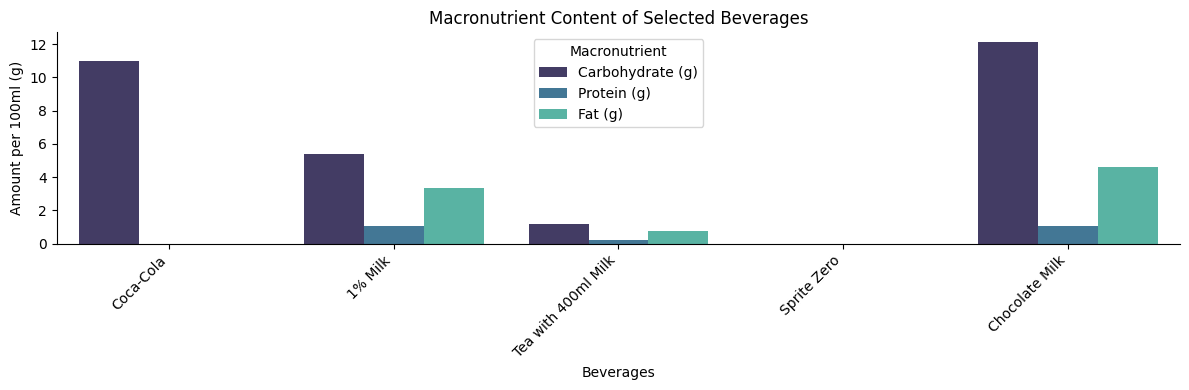

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import random

# Randomly select 5 items to plot
selected_items = ['Coke','milk_1','Tea_6Bags_Milk_400','SpriteZero','chocolate_milk']

# Prepare the data for plotting
data = []
for item in selected_items:
    carbs, protein, fat = macronutrient_targets[item]
    data.append({'Food': class_mapping.get(item, item), 'Macronutrient': 'Carbohydrate (g)', 'Amount': carbs})
    data.append({'Food': class_mapping.get(item, item), 'Macronutrient': 'Protein (g)', 'Amount': protein})
    data.append({'Food': class_mapping.get(item, item), 'Macronutrient': 'Fat (g)', 'Amount': fat})

# Convert to DataFrame
df = pd.DataFrame(data)

# Plotting using seaborn
plt.figure(figsize=(12, 4))
sns.barplot(x='Food', y='Amount', hue='Macronutrient', data=df, palette='mako')
plt.xticks(
    ticks=range(len(selected_items)),
    labels=[formal_mapping[item] for item in selected_items],
    rotation=45,  # Change to 45 degrees for better readability
    ha='right',   # Align the labels to the right
    fontsize=10
)
# Configure plot
plt.title('Macronutrient Content of Selected Beverages')
plt.xlabel('Beverages')
plt.ylabel('Amount per 100ml (g)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Macronutrient')
plt.tight_layout()

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.savefig('selected_macro.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
import os
import scipy.io
import numpy as np

# Get a list of all .mat files in the folder
filenames = [f for f in os.listdir(folder_path) if f.lower().endswith('.mat')]

# Data structures to store class data dynamically
class_data = {}

# Loop through each file
for filename in filenames:
    # Convert the filename to lowercase for case-insensitive comparison
    lower_filename = filename.lower()

    # Extract class name from filename up to '_box'
    if '_box' in lower_filename:
        class_name = lower_filename.split('_box')[0] + '_box'
        # Sanitize class name to ensure it is a valid identifier and make sure to check it in lowercase
        if class_name in class_mapping:
            formal_class_name = class_mapping[class_name]

            # Load the file
            file_path = os.path.join(folder_path, filename)
            loaded_data = scipy.io.loadmat(file_path)
            data = np.abs(loaded_data['rx_H_est_mat'][:11, :64])  # Take the first 11 rows and 64 columns of rx_H_est_mat

            # Append data to the respective class in the dict
            if formal_class_name in class_data:
                class_data[formal_class_name].append(data)
            else:
                class_data[formal_class_name] = [data]

# Example: Processing all collected classes for PCA
all_signals = []
class_names = []
labels = []
targets = []
current_label = 0

for formal_class_name, data_list in class_data.items():
    current_label += 1
    for data in data_list:
        all_signals.append(data)
        class_names.append(formal_class_name)
        labels.append(current_label)

        # Append target values for each sample in the class
        target_values = macronutrient_targets.get(formal_class_name, [0, 0, 0])
        targets.append(target_values)

all_signals = np.array(all_signals)
labels = np.array(labels)
targets = np.array(targets)
all_signals = np.nan_to_num(all_signals, nan=0.0)
class_names = np.array(class_names)


In [ ]:
processed_signals = []

for sample_data in all_signals:
    concatenated_data = None

    for channel in range(11):
        # Perform fftshift on the current channel
        shifted_channel = np.fft.fftshift(np.abs(sample_data[channel, :]))

        # Remove first 6 and last 6 elements after fftshift
        trimmed_channel = shifted_channel[6:58]

        if channel == 0:
            concatenated_data = trimmed_channel
        else:
            concatenated_data = np.concatenate([
                concatenated_data[:-36],
                (concatenated_data[-36:] + trimmed_channel[:36]) / 2,
                trimmed_channel[36:]
            ])


    # Append the processed sample to the list
    processed_signals.append(concatenated_data)

processed_signals = np.array(processed_signals)

In [ ]:
# Extract air samples from all_signals based on the corresponding class names
air_samples = [processed_signals[i] for i in range(len(processed_signals)) if class_names[i] == 'Air']
air_samples = np.array(air_samples)
# Calculate the average of all air samples
air_average = np.mean(air_samples, axis=0)

# Normalize all signals by the air average
normalized_signals = processed_signals / air_average

In [ ]:
# Remove the rows where the class name is 'air'
mask = class_names != 'Air'
normalized_signals = normalized_signals[mask]
class_names = class_names[mask]
targets =  targets[mask]

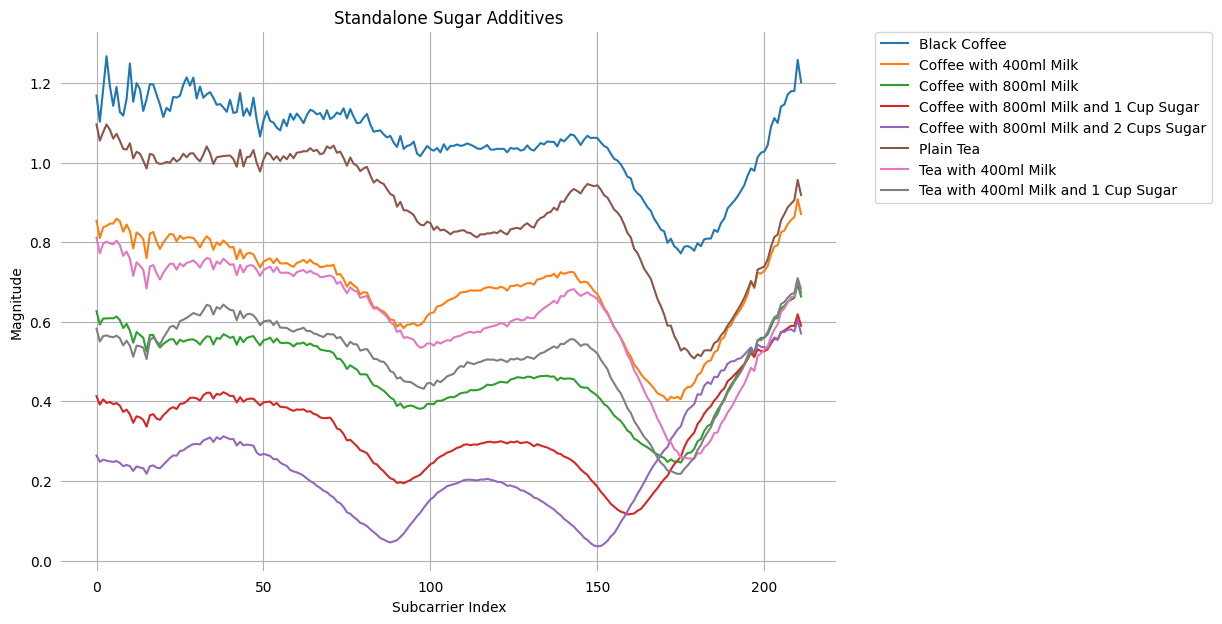

In [ ]:
# Get the unique class names
unique_classes = np.unique(class_names)

# Calculate the average of each class
averages = np.zeros((len(unique_classes), normalized_signals.shape[1]))

for i, cls in enumerate(unique_classes):
    class_mask = (class_names == cls)
    class_signals = normalized_signals[class_mask]
    averages[i] = np.mean(class_signals, axis=0)

# Plot the average of each class
plt.figure(figsize=(10, 7))
for i, cls in enumerate(unique_classes):
    # Get the formal name using the mapping
    formal_name = formal_mapping.get(cls, cls)  # Default to `cls` if no mapping exists
    target_value = macronutrient_targets.get(cls, [0, 0, 0])  # Default to [0, 0, 0] if no target
    plt.plot(range(normalized_signals.shape[1]), averages[i], label=f"{formal_name}")

# Remove the spines (outer boundaries)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# Remove the ticks as well (optional)
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')

# Add labels and legend
plt.title('Standalone Sugar Additives')
plt.xlabel('Subcarrier Index')
plt.ylabel('Magnitude')
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
plt.grid(True)

# Save the figure
plt.savefig('Standalone Sugar Additives_ofdm.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()


In [ ]:
import re, numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as F
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score, accuracy_score, classification_report
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# ------------------------------------------------------------------
# bring your prepared arrays into scope:
#   • normalized_signals : np.ndarray (N, 212)         -- CSI features
#   • class_names        : np.ndarray (N,)             -- raw strings
# ------------------------------------------------------------------
X_all = normalized_signals.astype(np.float32)
y_raw = class_names.astype(str)
N     = len(y_raw)

print(f"Loaded {N:,} samples  |  feature dim = {X_all.shape[1]}")

Loaded 1,449 samples  |  feature dim = 212


In [ ]:
def parse_hierarchy(name: str):
    name = name.lower()
    # --- Beverage branches ----------------------------------------
    if "water" in name:                            return ("water", "",            "",            "")
    if any(s in name for s in ("sprite","coke","fanta","ginger")):
        return ("soda", "zero" if ("zero" in name or "diet" in name) else "regular", "", "")
    if "protein"   in name:                        return ("supplements", "protein", "",           "")
    if "coffee"    in name:
        milk  = re.search(r"milk_(\d+)",  name)
        sugar = re.search(r"sugar_(\d+\.?\d*)", name)
        return ("coffee", f"milk{milk.group(1) if milk else '_0'}",
                         f"sugar{sugar.group(1) if sugar else '_0'}", "")
    if "tea"       in name:
        milk  = re.search(r"milk_(\d+)",  name)
        sugar = re.search(r"sugar_(\d+\.?\d*)", name)
        return ("tea", f"milk{milk.group(1) if milk else '_0'}",
                      f"sugar{sugar.group(1) if sugar else '_0'}", "")
    if "milk"      in name:
        fat   = "1%" if "1%" in name else ("2%" if "2%" in name else "whole")
        choc  = "choc" if "chocolate" in name else ""
        sugar = re.search(r"sugar_(\d+\.?\d*)", name)
        sug   = f"sugar{sugar.group(1)}" if sugar else ""
        addon = choc or sug or "plain"
        return ("milk", fat, addon, "")
    return ("unknown", "", "", "")

paths = np.array([parse_hierarchy(s) for s in y_raw])   # (N,4)
df    = pd.DataFrame(paths, columns=["L0","L1","L2","L3"])
df["leaf"] = y_raw


In [ ]:
def encode_column(col):
    uniq = {lbl:i for i,lbl in enumerate(np.unique(col))}
    return np.array([uniq[x] for x in col]), len(uniq)

yL0, nL0 = encode_column(df["L0"])
yL1, nL1 = encode_column(df["L1"])
yL2, nL2 = encode_column(df["L2"])      # L3 empty; we ignore

y_leaf, n_leaf = encode_column(df["leaf"])

print(f"Levels:  L0={nL0}  L1={nL1}  L2={nL2}  leaf={n_leaf}")


Levels:  L0=2  L1=3  L2=3  leaf=8


In [ ]:
class CsiHierDataset(Dataset):
    def __init__(self, idx):
        self.X   = torch.tensor(X_all[idx])
        self.y0  = torch.tensor(yL0[idx])
        self.y1  = torch.tensor(yL1[idx])
        self.y2  = torch.tensor(yL2[idx])
        self.yl  = torch.tensor(y_leaf[idx])
    def __len__(self): return len(self.X)
    def __getitem__(self,i):
        return self.X[i], self.y0[i], self.y1[i], self.y2[i], self.yl[i]

batch = 512
train_loader = DataLoader(CsiHierDataset(train_idx), batch_size=batch, shuffle=True)
val_loader   = DataLoader(CsiHierDataset(val_idx),   batch_size=batch)
test_loader  = DataLoader(CsiHierDataset(test_idx),  batch_size=batch)


In [ ]:
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=42)
train_val_idx, test_idx = next(sss1.split(np.zeros(N), y_leaf))

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.1111, random_state=42) # 0.1111×0.9 ≈ 0.10
train_idx, val_idx = next(sss2.split(np.zeros(len(train_val_idx)), y_leaf[train_val_idx]))

train_idx = train_val_idx[train_idx]
val_idx   = train_val_idx[val_idx]

print(f"Train {len(train_idx)} | Val {len(val_idx)} | Test {len(test_idx)}")


Train 1159 | Val 145 | Test 145


In [ ]:
class Encoder1D(nn.Module):
    def __init__(self, emb_dim=128):
        super().__init__()
        self.fe = nn.Sequential(
            nn.Conv1d(1,32,5, padding=2), nn.BatchNorm1d(32), nn.GELU(),
            nn.Conv1d(32,64,5, padding=2), nn.BatchNorm1d(64), nn.GELU(),
            nn.Conv1d(64,64,3, padding=1), nn.BatchNorm1d(64), nn.GELU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(64, emb_dim), nn.GELU())
    def forward(self,x):           # x:(B,212)
        return self.fe(x.unsqueeze(1))  # → (B,emb)

class HierClassifier(nn.Module):
    def __init__(self, emb_dim, nL0,nL1,nL2,n_leaf):
        super().__init__()
        self.enc = Encoder1D(emb_dim)
        self.h0  = nn.Linear(emb_dim, nL0)
        self.h1  = nn.Linear(emb_dim, nL1)
        self.h2  = nn.Linear(emb_dim, nL2)
        self.hL  = nn.Linear(emb_dim, n_leaf)
    def forward(self,x):
        z  = self.enc(x)
        return self.h0(z), self.h1(z), self.h2(z), self.hL(z)


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = HierClassifier(128, nL0,nL1,nL2,n_leaf).to(device)
opt    = torch.optim.Adam(model.parameters(), lr=3e-4)
ce     = nn.CrossEntropyLoss()

def run_epoch(loader, train=True):
    if train: model.train()
    else:     model.eval()
    tot_loss=0; preds=[]; trues=[]
    with torch.set_grad_enabled(train):
        for X,y0,y1,y2,yl in loader:
            X,y0,y1,y2,yl = [t.to(device) for t in (X,y0,y1,y2,yl)]
            o0,o1,o2,oL   = model(X)
            loss = (ce(o0,y0)+ce(o1,y1)+ce(o2,y2)+ce(oL,yl))/4
            if train:
                opt.zero_grad(); loss.backward(); opt.step()
            tot_loss += loss.item()*X.size(0)
            preds.append(oL.argmax(1).cpu()); trues.append(yl.cpu())
    return tot_loss/len(loader.dataset), torch.cat(preds), torch.cat(trues)

for epoch in range(30):
    tr_loss, _, _ = run_epoch(train_loader, train=True)
    val_loss, pv, tv = run_epoch(val_loader,   train=False)
    macro = f1_score(tv, pv, average='macro')
    print(f"Ep{epoch+1:02d}  train loss {tr_loss:.3f} | val loss {val_loss:.3f} | val macro-F1 {macro:.3f}")


Ep01  train loss 1.233 | val loss 1.237 | val macro-F1 0.030
Ep02  train loss 1.178 | val loss 1.234 | val macro-F1 0.030
Ep03  train loss 1.132 | val loss 1.229 | val macro-F1 0.030
Ep04  train loss 1.094 | val loss 1.222 | val macro-F1 0.030
Ep05  train loss 1.060 | val loss 1.211 | val macro-F1 0.030
Ep06  train loss 1.027 | val loss 1.197 | val macro-F1 0.030
Ep07  train loss 0.997 | val loss 1.177 | val macro-F1 0.032
Ep08  train loss 0.970 | val loss 1.150 | val macro-F1 0.164
Ep09  train loss 0.940 | val loss 1.115 | val macro-F1 0.154
Ep10  train loss 0.914 | val loss 1.070 | val macro-F1 0.243
Ep11  train loss 0.889 | val loss 1.021 | val macro-F1 0.435
Ep12  train loss 0.865 | val loss 0.972 | val macro-F1 0.468
Ep13  train loss 0.840 | val loss 0.925 | val macro-F1 0.459
Ep14  train loss 0.819 | val loss 0.882 | val macro-F1 0.435
Ep15  train loss 0.798 | val loss 0.843 | val macro-F1 0.499
Ep16  train loss 0.778 | val loss 0.809 | val macro-F1 0.483
Ep17  train loss 0.757 |

In [ ]:
_, p_test, t_test = run_epoch(test_loader, train=False)
print(classification_report(t_test, p_test, digits=3))


              precision    recall  f1-score   support

           0      0.952     1.000     0.976        20
           1      0.500     1.000     0.667        20
           2      0.857     0.947     0.900        19
           3      0.933     0.778     0.848        18
           4      0.818     1.000     0.900        18
           5      1.000     0.950     0.974        20
           6      0.000     0.000     0.000        20
           7      0.000     0.000     0.000        10

    accuracy                          0.752       145
   macro avg      0.633     0.709     0.658       145
weighted avg      0.668     0.752     0.696       145



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [ ]:
# ------------------------------------------------------------------
# REBUILD split arrays (safe even if they already exist)
# ------------------------------------------------------------------
X_train = normalized_signals[train_idx]
X_val   = normalized_signals[val_idx]
X_test  = normalized_signals[test_idx]

y_train = y_leaf[train_idx]
y_val   = y_leaf[val_idx]
y_test  = y_leaf[test_idx]


In [ ]:
# -------------------------------------------------------------
# 0.  Get PREDICTIONS for every test sample (leaf-level logits)
# -------------------------------------------------------------
import torch, numpy as np, pandas as pd, plotly.express as px

model.eval()
pred_ints = []

with torch.no_grad():
    for X_batch, *_ , _ in test_loader:      # loader yields (X, y0, y1, y2, y_leaf)
        logits_leaf = model(X_batch.to(device))[-1]   # last output = leaf logits
        pred_ints.append(logits_leaf.argmax(1).cpu())

pred_ints = torch.cat(pred_ints).numpy()               # shape (len(test),)

# -------------------------------------------------------------
# 1.  Build integer↔string mapping for leaf classes
# -------------------------------------------------------------
leaf_unique = np.unique(df["leaf"])
int_to_leaf = {i: lbl for i, lbl in enumerate(leaf_unique)}

true_names = df["leaf"].iloc[test_idx].to_numpy()      # ground-truth strings (test set)
pred_names = np.array([int_to_leaf[i] for i in pred_ints])

# -------------------------------------------------------------
# 2.  Create DataFrame with TRUE + PREDICTED hierarchy columns
# -------------------------------------------------------------
df_test = df.iloc[test_idx].copy()                     # keep true hierarchy columns
df_test["pred_leaf"] = pred_names

# parse predicted hierarchy path into columns pL0, pL1, pL2
pred_paths = np.array([parse_hierarchy(s) for s in pred_names])
df_test[["pL0", "pL1", "pL2", "pL3"]] = pred_paths

# -------------------------------------------------------------
# 3.  Aggregate counts for TRUE and PREDICTED
# -------------------------------------------------------------
true_tree = (
    df_test
    .groupby(["L0", "L1", "L2"], dropna=False)
    .size().reset_index(name="count")
)

pred_tree = (
    df_test
    .groupby(["pL0", "pL1", "pL2"], dropna=False)
    .size().reset_index(name="count")
    .rename(columns={"pL0":"L0", "pL1":"L1", "pL2":"L2"})
)

# -------------------------------------------------------------
# 4.  Plot treemaps side-by-side (TRUE vs PREDICTED)
# -------------------------------------------------------------
fig_true = px.treemap(
    true_tree, path=["L0","L1","L2"], values="count",
    color="L0", title="TRUE distribution on TEST set"
)
fig_pred = px.treemap(
    pred_tree, path=["L0","L1","L2"], values="count",
    color="L0", title="PREDICTED distribution on TEST set"
)

# Display
fig_true.show()
fig_pred.show()


# Hierarchical CSI Pipeline

Loaded 1,449 samples → tensor torch.Size([1449, 212])


SimCLR epoch 1: 100%|██████████| 4/4 [00:02<00:00,  1.70it/s]


Epoch 01 | contrastive loss: 5.7042


SimCLR epoch 2: 100%|██████████| 4/4 [00:02<00:00,  1.82it/s]


Epoch 02 | contrastive loss: 5.1947


...

Epoch 18 | contrastive loss: 4.0551


SimCLR epoch 19: 100%|██████████| 4/4 [00:02<00:00,  1.96it/s]


Epoch 19 | contrastive loss: 4.0006


SimCLR epoch 20: 100%|██████████| 4/4 [00:02<00:00,  1.92it/s]


Epoch 20 | contrastive loss: 4.0192
Embeddings shape: torch.Size([1449, 128])
Coarse ≈ 27 | Fine ≈ 40
RegEpoch 01 | train MSE 2.3336 | val MSE 1.8112
RegEpoch 02 | train MSE 2.1033 | val MSE 1.7283
RegEpoch 03 | train MSE 1.8980 | val MSE 1.6401
RegEpoch 04 | train MSE 1.9020 | val MSE 1.5461
RegEpoch 05 | train MSE 1.5475 | val MSE 1.4394
RegEpoch 06 | train MSE 1.7264 | val MSE 1.3342
RegEpoch 07 | train MSE 1.6512 | val MSE 1.2205
RegEpoch 08 | train MSE 1.2993 | val MSE 1.0931
RegEpoch 09 | train MSE 1.2778 | val MSE 0.9747
RegEpoch 10 | train MSE 0.9058 | val MSE 0.8519
RegEpoch 11 | train MSE 1.0033 | val MSE 0.7404
RegEpoch 12 | train MSE 0.6950 | val MSE 0.6307
RegEpoch 13 | train MSE 0.5399 | val MSE 0.5294
RegEpoch 14 | train MSE 0.4751 | val MSE 0.4378
RegEpoch 15 | train MSE 0.4447 | val MSE 0.3611
RegEpoch 16 | train MSE 0.4010 | val MSE 0.3012
RegEpoch 17 | train MSE 0.2959 | val MSE 0.2486
RegEpoch 18 | train MSE 0.2886 | val MSE 0.2063
RegEpoch 19 | train MSE 0.2183 | v

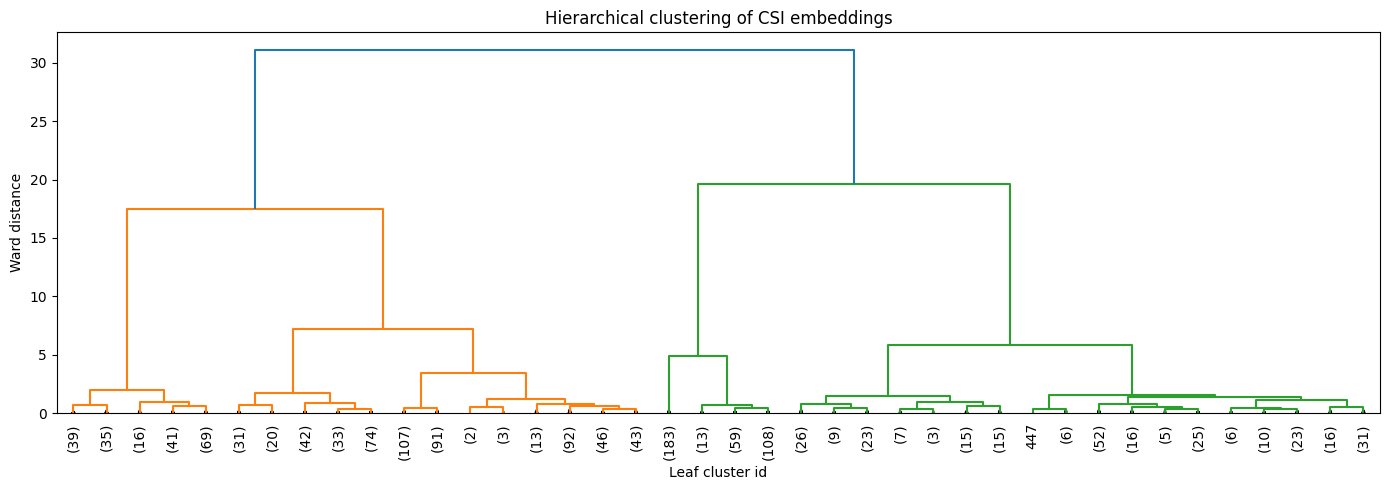

In [ ]:
# --------------------------------------------------
# 0. DATA LOADING & NORMALISATION
# --------------------------------------------------
import numpy as np
import torch
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import OneHotEncoder


# -------------------------------------------------------------------
# Bring in your prepared arrays (replace these placeholders):
#   normalized_signals : np.ndarray (N, 212)
#   class_names        : np.ndarray (N,) (original labels, may be unknown)
#   targets            : np.ndarray (N, 3)  [kcal, carb, protein]
# -------------------------------------------------------------------

X_all   = torch.tensor(normalized_signals, dtype=torch.float32)  # (N, 212)
Y_macro = torch.tensor(targets,            dtype=torch.float32)  # (N, 3)
print(f"Loaded {X_all.shape[0]:,} samples → tensor {X_all.shape}")

# Stratified split (by the *original* class names, just to avoid leakage)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(sss.split(X_all, class_names))

val_split = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
train_idx, val_idx = next(val_split.split(X_all[train_idx], class_names[train_idx]))
train_idx = torch.tensor(train_idx); val_idx = torch.tensor(val_idx); test_idx = torch.tensor(test_idx)

# --------------------------------------------------
# 1. SELF‑SUPERVISED REPRESENTATION LEARNING (SimCLR)
# --------------------------------------------------
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

class CsiAugment:
    """Basic augmentations for 212‑dim CSI amplitude/phase vector."""
    def __init__(self, noise_std=0.02, feature_drop=0.15):
        self.noise_std = noise_std
        self.feature_drop = feature_drop
    def __call__(self, x):  # x: (212,)
        x = x + torch.randn_like(x) * self.noise_std
        if self.feature_drop > 0:
            mask = (torch.rand_like(x) > self.feature_drop).float()
            x = x * mask
        return x

class SimCLRDataset(Dataset):
    def __init__(self, X, augment):
        self.X = X
        self.augment = augment
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        xi = self.X[idx]
        # return two augmented views with a channel dim (1, 212)
        return self.augment(xi).unsqueeze(0), self.augment(xi).unsqueeze(0)

class TinyCsiCNN1D(nn.Module):
    """≈30 k parameters 1‑D CNN encoder for (B, 1, 212)."""
    def __init__(self, embed_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5, padding=2), nn.BatchNorm1d(32), nn.GELU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=2), nn.BatchNorm1d(64), nn.GELU(),
            nn.Conv1d(64, 64, kernel_size=3, padding=1), nn.BatchNorm1d(64), nn.GELU(),
            nn.AdaptiveAvgPool1d(1),   # → (B, 64, 1)
            nn.Flatten(),               # → (B, 64)
            nn.Linear(64, embed_dim)
        )
    def forward(self, x):            # x: (B, 1, 212)
        z = self.net(x)
        return F.normalize(z, dim=1)

class ProjectionHead(nn.Module):
    def __init__(self, in_dim, proj_dim=64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, in_dim), nn.GELU(), nn.Linear(in_dim, proj_dim)
        )
    def forward(self, z):
        return F.normalize(self.mlp(z), dim=1)

# NT‑Xent contrastive loss
def nt_xent(z1, z2, temperature=0.07):
    B = z1.size(0)
    z = torch.cat([z1, z2], dim=0)
    sim = torch.mm(z, z.t()) / temperature
    labels = torch.arange(B, device=z.device)
    labels = torch.cat([labels, labels], dim=0)
    loss = F.cross_entropy(sim, labels)
    return loss

# ------------ training loop ------------
embed_dim = 128
batch_size = 256
augment = CsiAugment()
train_loader = DataLoader(SimCLRDataset(X_all[train_idx], augment),
                          batch_size=batch_size, shuffle=True, drop_last=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
encoder = TinyCsiCNN1D(embed_dim).to(device)
proj    = ProjectionHead(embed_dim).to(device)
params  = list(encoder.parameters()) + list(proj.parameters())
opt     = torch.optim.Adam(params, lr=3e-4)

for epoch in range(20):
    total = 0
    encoder.train(); proj.train()
    for x1, x2 in tqdm(train_loader, desc=f"SimCLR epoch {epoch+1}"):
        x1, x2 = x1.to(device), x2.to(device)       # (B,1,212)
        z1 = proj(encoder(x1))
        z2 = proj(encoder(x2))
        loss = nt_xent(z1, z2)
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item()
    print(f"Epoch {epoch+1:02d} | contrastive loss: {total/len(train_loader):.4f}")

# --------------------------------------------------
# 1b. EXTRACT EMBEDDINGS FOR ALL SAMPLES
# --------------------------------------------------
@torch.no_grad()
def get_embeddings(model, X_tensor):
    model.eval()
    loader = DataLoader(X_tensor, batch_size=1024)
    Z = []
    for x in loader:
        z = model(x.unsqueeze(1).to(device))  # add channel dim on the fly
        Z.append(z.cpu())
    return torch.cat(Z, dim=0)

Z_all = get_embeddings(encoder, X_all)
print("Embeddings shape:", Z_all.shape)

# --------------------------------------------------
# 2. CATEGORY DISCOVERY (HIERARCHICAL CLUSTERING)
# --------------------------------------------------
from scipy.cluster.hierarchy import linkage, fcluster
Z_link = linkage(Z_all.numpy(), method="ward")

# Choose desired #clusters at fine level (e.g., 40)
fine_clusters = fcluster(Z_link, t=40, criterion='maxclust')

# Coarse clusters via inconsistency threshold
from scipy.cluster.hierarchy import inconsistent
inc = inconsistent(Z_link)
coarse_clusters = fcluster(Z_link, t=np.mean(inc[:,3]), criterion='distance')

print("Coarse ≈", np.unique(coarse_clusters).size, "| Fine ≈", np.unique(fine_clusters).size)

# --------------------------------------------------
# 3. MACRO‑NUTRIENT REGRESSION WITH CLUSTER GUIDANCE
# --------------------------------------------------
# works on both old and new scikit-learn
try:
    onehot = OneHotEncoder(sparse_output=False)   # >= 1.2
except TypeError:
    onehot = OneHotEncoder(sparse=False)          # < 1.2
cluster_oh = onehot.fit_transform(fine_clusters.reshape(-1,1))

from torch.utils.data import TensorDataset
train_ds = TensorDataset(X_all[train_idx], torch.tensor(cluster_oh[train_idx], dtype=torch.float32), Y_macro[train_idx])
val_ds   = TensorDataset(X_all[val_idx],   torch.tensor(cluster_oh[val_idx],   dtype=torch.float32), Y_macro[val_idx])
train_loader_reg = DataLoader(train_ds, batch_size=512, shuffle=True)
val_loader_reg   = DataLoader(val_ds,   batch_size=512)

class MacroRegressor(nn.Module):
    def __init__(self, frozen_encoder, emb_dim, cluster_dim, out_dim=3):
        super().__init__()
        self.encoder = frozen_encoder
        for p in self.encoder.parameters():
            p.requires_grad = False
        self.fc = nn.Sequential(
            nn.Linear(emb_dim + cluster_dim, 128), nn.GELU(),
            nn.Linear(128, out_dim)
        )
    def forward(self, x, p):
        z = self.encoder(x.unsqueeze(1))
        h = torch.cat([z, p], dim=1)
        return self.fc(h)

reg_model = MacroRegressor(encoder, embed_dim, cluster_oh.shape[1]).to(device)
reg_opt   = torch.optim.Adam(reg_model.fc.parameters(), lr=1e-3)
reg_crit  = nn.MSELoss()

for epoch in range(50):
    reg_model.train(); tr_tot=0
    for x, p, y in train_loader_reg:
        x, p, y = x.to(device), p.to(device), y.to(device)
        y_hat = reg_model(x, p)
        loss = reg_crit(y_hat, y)
        reg_opt.zero_grad(); loss.backward(); reg_opt.step(); tr_tot += loss.item()
    # validation
    reg_model.eval(); v_tot=0
    with torch.no_grad():
        for x, p, y in val_loader_reg:
            x, p, y = x.to(device), p.to(device), y.to(device)
            v_tot += reg_crit(reg_model(x, p), y).item()
    print(f"RegEpoch {epoch+1:02d} | train MSE {tr_tot/len(train_loader_reg):.4f} | val MSE {v_tot/len(val_loader_reg):.4f}")

# --------------------------------------------------
# 4. OPTIONAL – VISUALISATION SNIPPETS (UMAP + dendrogram)
# --------------------------------------------------
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

# Z_link produced earlier (Ward linkage on embeddings)
plt.figure(figsize=(14, 5))
dendrogram(
    Z_link,
    truncate_mode="lastp",  # show only the last p merged clusters
    p=40,                   # adjust to match your fine-cluster count
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True,
    color_threshold=None    # let distance decide colours
)
plt.title("Hierarchical clustering of CSI embeddings")
plt.xlabel("Leaf cluster id")
plt.ylabel("Ward distance")
plt.tight_layout()
plt.show()


/tmp/ipython-input-49-3097209121.py:15: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



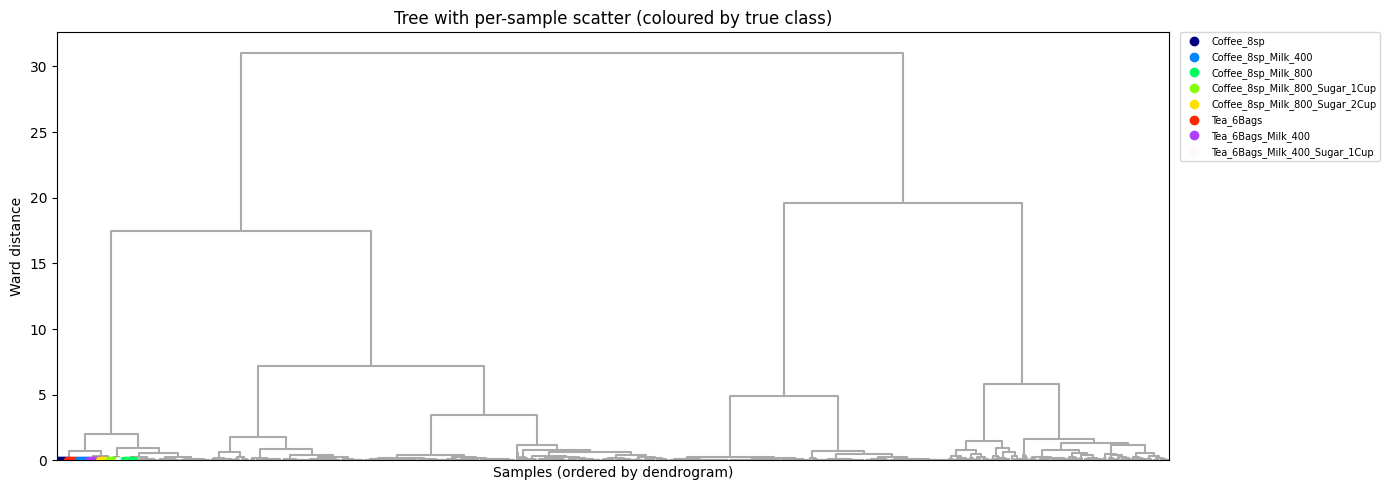

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.cluster.hierarchy import dendrogram

def scatter_tree_with_legend(Z_link, class_names,
                             palette="gist_ncar",
                             point_size=16,
                             dot_spacing=1.5,          # smaller = tighter
                             figsize=(16, 6),
                             legend_fontsize=7):

    N = len(class_names)
    uniq = np.unique(class_names)
    cmap = cm.get_cmap(palette, len(uniq))
    color_map = {cls: cmap(i) for i, cls in enumerate(uniq)}

    fig, ax = plt.subplots(figsize=figsize)
    dendro = dendrogram(Z_link,
                        no_labels=True,
                        color_threshold=None,
                        link_color_func=lambda k: "#aaaaaa",
                        ax=ax)

    # Dots: tighter x spacing
    leaf_order = dendro["leaves"]
    x_coords = np.arange(len(leaf_order)) * dot_spacing
    y_coords = np.zeros_like(x_coords)
    colors = [color_map[class_names[idx]] for idx in leaf_order]

    ax.scatter(x_coords, y_coords, c=colors, s=point_size, zorder=3)

    # Clean axis
    ax.set_xticks([])
    ax.set_xlabel("Samples (ordered by dendrogram)")
    ax.set_ylabel("Ward distance")
    ax.set_title("Tree with per-sample scatter (coloured by true class)")

    # Legend
    handles = [plt.Line2D([0], [0], marker='o', linestyle='',
                          color=color_map[c], label=c, markersize=6)
               for c in uniq]
    ax.legend(handles=handles, bbox_to_anchor=(1.01, 1),
              loc='upper left', fontsize=legend_fontsize, borderaxespad=0.)
    plt.tight_layout()
    plt.show()

# -----------------------
# USAGE
# -----------------------
scatter_tree_with_legend(Z_link, class_names,
                         dot_spacing=0.7,        # try 0.5–1.0 for compact view
                         figsize=(14, 5))


<ipython-input-41-0105e92be962>:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(unique_classes))
<ipython-input-41-0105e92be962>:17: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  ax = plt.gca()  # Get the current Axes instance


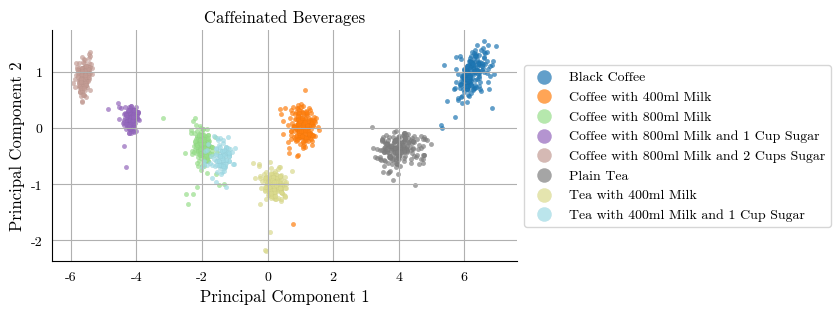

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Flatten each sample in normalized_signals to a 1D array
flattened_signals = normalized_signals.reshape(normalized_signals.shape[0], -1)

# Perform PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
reduced_signals = pca.fit_transform(flattened_signals)

# Create a scatter plot with distinct colors and controlled opacity
unique_classes = np.unique(class_names)
colors = plt.cm.get_cmap('tab20', len(unique_classes))

plt.figure(figsize=(6, 3))
ax = plt.gca()  # Get the current Axes instance

point_size = 12  # Set uniform size of points
opacity = 0.7  # Set alpha (opacity) for transparency
boundary_color = 'black'  # Set boundary color for points
boundary_width = 0.01  # Set boundary thickness

for idx, class_name in enumerate(unique_classes):
    indices = np.where(class_names == class_name)
    formal_name = formal_mapping.get(class_name, class_name)  # Use formal names if available
    plt.scatter(
        reduced_signals[indices, 0], reduced_signals[indices, 1],
        label=formal_name,
        color=colors(idx),
        s=point_size,
        alpha=opacity,
        edgecolors=boundary_color,  # Set the boundary color
        linewidth=boundary_width    # Set the boundary thickness
    )

# Remove the spines (outer boundaries)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Remove the ticks as well (optional)
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')
ax.grid(True)

# Add labels, title, and legend
plt.title('Caffeinated Beverages', fontsize = 12)
plt.xlabel('Principal Component 1', fontsize = 12)
plt.ylabel('Principal Component 2', fontsize = 12)

# Use the scatterpoints parameter to control legend marker size
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1, scatterpoints=1, markerscale=3)

# Save and show the plot
plt.savefig('Caffeinated_Beverages.png', dpi=300, bbox_inches='tight')
plt.show()


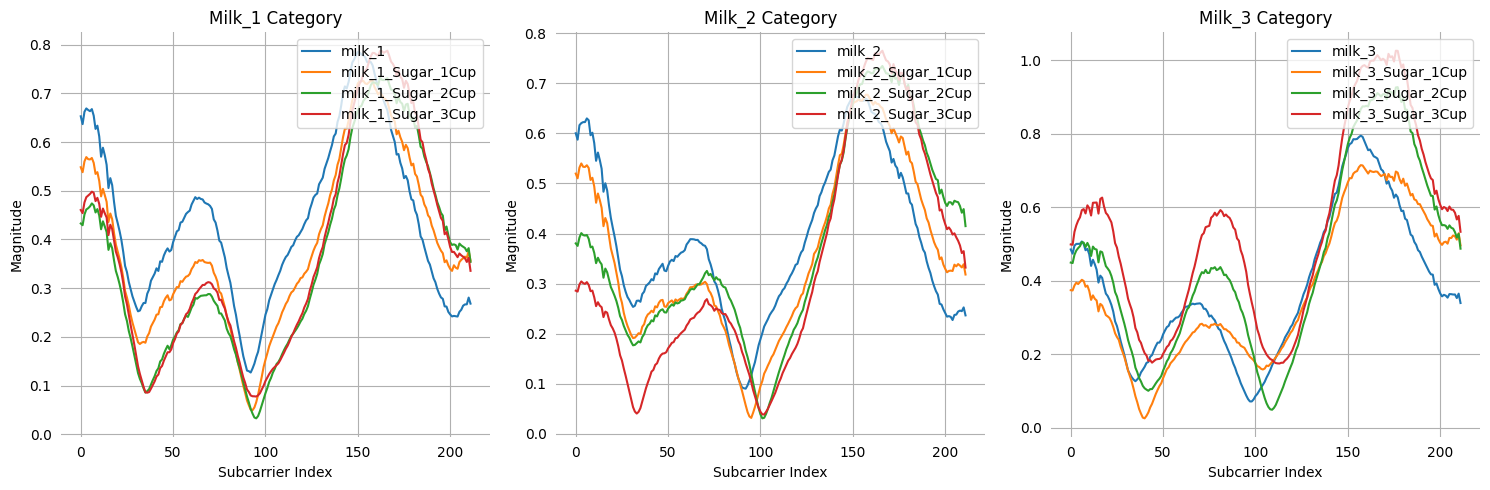

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming normalized_signals is a numpy array of shape (2231, 212)
# and class_names is a numpy array of shape (2231,)
# Also assuming macronutrient_target is a dictionary with class names as keys and tuples as values
# where the second element of the tuple is the target value.

# Define categories for Sugar, Soda, and Milk
Caffeinated_classes = ['Coffee_8sp','Coffee_8sp_Milk_400','Coffee_8sp_Milk_800','Coffee_8sp_Milk_800_Sugar_1Cup','Coffee_8sp_Milk_800_Sugar_2Cup','Tea_6Bags','Tea_6Bags_Milk_400','Tea_6Bags_Milk_400_Sugar_1Cup']
#sugar_classes = ['Sugar_0.5Cup', 'Sugar_1Cup', 'Sugar_1.5Cup', 'Sugar_2Cup', 'Sugar_2.5Cup', 'Sugar_3Cup']
#soda_classes = ['Coke', 'DietCoke', 'Fanta', 'Sprite', 'Ginger', 'SpriteZero']
soda_classes = ['milk_1','milk_1_Sugar_1Cup','milk_1_Sugar_2Cup','milk_1_Sugar_3Cup']
milk_classes = ['milk_2','milk_2_Sugar_1Cup','milk_2_Sugar_2Cup','milk_2_Sugar_3Cup']
sugar_classes = ['milk_3','milk_3_Sugar_1Cup','milk_3_Sugar_2Cup','milk_3_Sugar_3Cup']


# Function to plot category data
def plot_category(ax, category_classes, category_name):
    for cls in category_classes:
        class_mask = (class_names == cls)
        class_signals = normalized_signals[class_mask]
        average_signal = np.mean(class_signals, axis=0)
        ax.plot(range(normalized_signals.shape[1]), average_signal, label=f"{cls}")

    # Remove the spines (outer boundaries)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    # Remove the ticks as well (optional)
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')

    ax.set_xlabel('Subcarrier Index')
    ax.set_ylabel('Magnitude')
    ax.set_title(f'{category_name} Category')
    ax.legend(loc='upper right')
    ax.grid(True)

# Create a figure with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot for each category

plot_category(axes[0], soda_classes, 'Milk_1')
#plot_category(axes[2], Caffeinated_classes, 'Caffeinated')
plot_category(axes[1], milk_classes, 'Milk_2')
plot_category(axes[2], sugar_classes, 'Milk_3')

# Adjust layout to prevent overlap
plt.tight_layout()

# Save the combined figure
#plt.savefig('combined_sugar_soda_milk.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 4.5 MB/s eta 0:00:00


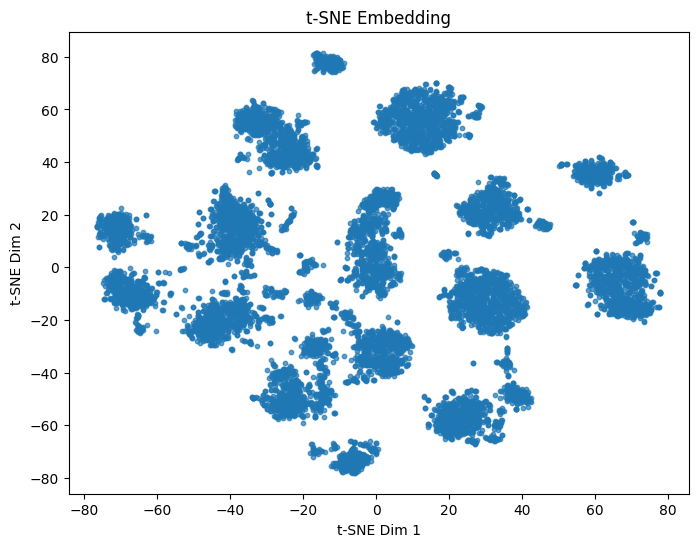

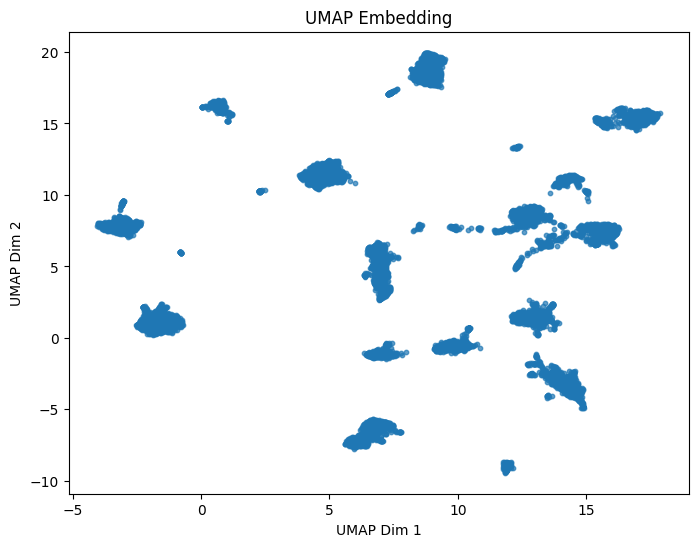

In [ ]:
!pip install umap-learn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap.umap_ as umap
from sklearn.preprocessing import StandardScaler

# Load your normalized_signals
# Assuming `normalized_signals` is a numpy array
# normalized_signals = np.load("path_to_normalized_signals.npy")  # Uncomment to load your data

# Standardize the data (important for t-SNE and UMAP)
scaler = StandardScaler()
normalized_signals_scaled = scaler.fit_transform(normalized_signals)

# t-SNE embedding
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=1000, random_state=42)
tsne_embedding = tsne.fit_transform(normalized_signals_scaled)

# Plot t-SNE result
plt.figure(figsize=(8, 6))
plt.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1], s=10, alpha=0.7)
plt.title('t-SNE Embedding')
plt.xlabel('t-SNE Dim 1')
plt.ylabel('t-SNE Dim 2')
plt.show()

# UMAP embedding
umap_reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
umap_embedding = umap_reducer.fit_transform(normalized_signals_scaled)

# Plot UMAP result
plt.figure(figsize=(8, 6))
plt.scatter(umap_embedding[:, 0], umap_embedding[:, 1], s=10, alpha=0.7)
plt.title('UMAP Embedding')
plt.xlabel('UMAP Dim 1')
plt.ylabel('UMAP Dim 2')
plt.show()

Epoch 1/20, Loss: 1090.0961
Epoch 2/20, Loss: 1090.0454
Epoch 3/20, Loss: 1090.0452
Epoch 4/20, Loss: 1090.0418
Epoch 5/20, Loss: 1090.0343
Epoch 6/20, Loss: 1090.0393
Epoch 7/20, Loss: 1090.0382
Epoch 8/20, Loss: 1090.0475
Epoch 9/20, Loss: 1090.0349
Epoch 10/20, Loss: 1090.0338
Epoch 11/20, Loss: 1090.0333
Epoch 12/20, Loss: 1090.0337
Epoch 13/20, Loss: 1090.0343
Epoch 14/20, Loss: 1090.0332
Epoch 15/20, Loss: 1090.0340
Epoch 16/20, Loss: 1090.0338
Epoch 17/20, Loss: 1090.0366
Epoch 18/20, Loss: 1090.0358
Epoch 19/20, Loss: 1090.0344
Epoch 20/20, Loss: 1090.0331
315/315 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


<ipython-input-19-2a9e3e1be590>:97: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axes[0].scatter(tsne_before[:, 0], tsne_before[:, 1], alpha=0.7, cmap='viridis')
<ipython-input-19-2a9e3e1be590>:102: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axes[1].scatter(encoded_after[:, 0], encoded_after[:, 1], alpha=0.7, cmap='viridis')


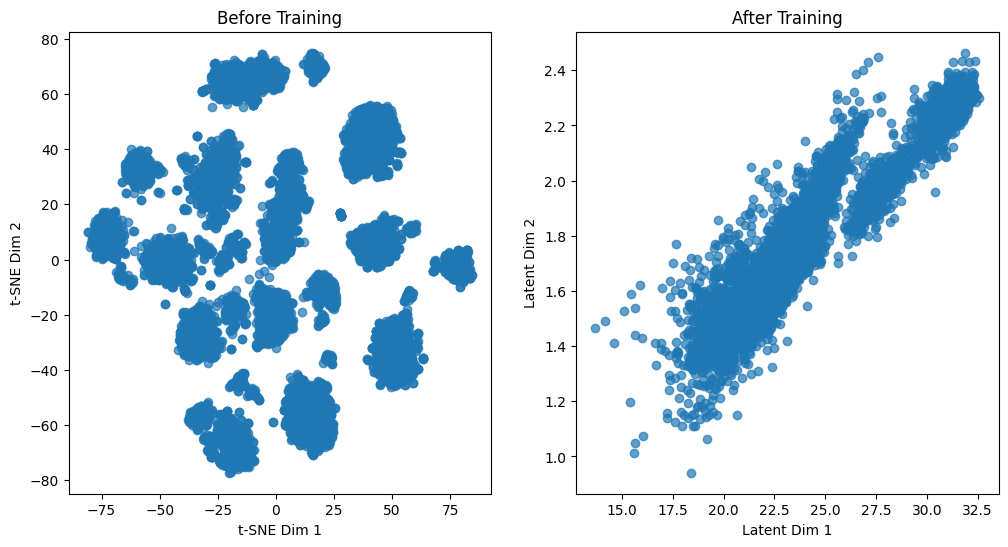

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Normalized signals (already processed as described in the prompt)
#normalized_signals = np.random.rand(1000, 50)  # Replace with your actual normalized_signals array

# Define Encoder
def build_encoder(input_dim, latent_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(latent_dim, activation=None)  # Linear output for latent space
    ], name="encoder")
    return model

# Contrastive Loss (NT-Xent style)
class ContrastiveLoss(tf.keras.losses.Loss):
    def __init__(self, temperature=0.1):
        super(ContrastiveLoss, self).__init__()
        self.temperature = temperature

    def call(self, z_i, z_j):
        # Normalize embeddings
        z_i = tf.math.l2_normalize(z_i, axis=1)
        z_j = tf.math.l2_normalize(z_j, axis=1)

        # Compute similarity matrix
        similarity_matrix = tf.matmul(z_i, z_j, transpose_b=True)
        logits = similarity_matrix / self.temperature

        # Labels for contrastive learning (positive pairs on diagonal)
        labels = tf.range(tf.shape(z_i)[0])

        # Contrastive loss
        return tf.reduce_mean(tf.nn.sparse_softmax_cross_entropy_with_logits(labels, logits))

# DataLoader for Positive/Negative Pair Generation
def create_pairs(data):
    n = data.shape[0]
    idxs = np.arange(n)
    np.random.shuffle(idxs)
    positive_pairs = [(data[i], data[(i + 1) % n]) for i in idxs]  # Adjacent samples
    negative_pairs = [(data[i], data[(i + n//2) % n]) for i in idxs]  # Distant samples
    return positive_pairs, negative_pairs

# Training Loop
latent_dim = 2  # For visualization
input_dim = normalized_signals.shape[1]
batch_size = 32
num_epochs = 20

encoder = build_encoder(input_dim, latent_dim)
optimizer = optimizers.Adam(learning_rate=0.001)
contrastive_loss_fn = ContrastiveLoss(temperature=0.1)

for epoch in range(num_epochs):
    np.random.shuffle(normalized_signals)
    positive_pairs, negative_pairs = create_pairs(normalized_signals)

    total_loss = 0
    for batch_start in range(0, len(positive_pairs), batch_size):
        batch_end = batch_start + batch_size
        pos_pairs = positive_pairs[batch_start:batch_end]
        neg_pairs = negative_pairs[batch_start:batch_end]

        # Prepare batch data
        z_i = np.array([p[0] for p in pos_pairs])
        z_j = np.array([p[1] for p in pos_pairs])

        # Forward pass
        with tf.GradientTape() as tape:
            z_i_encoded = encoder(z_i, training=True)
            z_j_encoded = encoder(z_j, training=True)
            loss = contrastive_loss_fn(z_i_encoded, z_j_encoded)

        # Backward pass
        gradients = tape.gradient(loss, encoder.trainable_variables)
        optimizer.apply_gradients(zip(gradients, encoder.trainable_variables))

        total_loss += loss.numpy()

    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {total_loss:.4f}")

# Visualize Before and After Training
# t-SNE before training
tsne_before = TSNE(n_components=2).fit_transform(normalized_signals)

# Latent space after training
encoded_after = encoder.predict(normalized_signals)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].scatter(tsne_before[:, 0], tsne_before[:, 1], alpha=0.7, cmap='viridis')
axes[0].set_title("Before Training")
axes[0].set_xlabel("t-SNE Dim 1")
axes[0].set_ylabel("t-SNE Dim 2")

axes[1].scatter(encoded_after[:, 0], encoded_after[:, 1], alpha=0.7, cmap='viridis')
axes[1].set_title("After Training")
axes[1].set_xlabel("Latent Dim 1")
axes[1].set_ylabel("Latent Dim 2")

plt.show()


Epoch 1/20, Domain Loss: 218.5821, Contrastive Loss: 1089.9450
Epoch 2/20, Domain Loss: 218.9661, Contrastive Loss: 1089.5112
Epoch 3/20, Domain Loss: 218.8064, Contrastive Loss: 1089.3778
Epoch 4/20, Domain Loss: 219.6445, Contrastive Loss: 1089.2295
Epoch 5/20, Domain Loss: 218.9376, Contrastive Loss: 1089.1189
Epoch 6/20, Domain Loss: 219.0241, Contrastive Loss: 1089.0960
Epoch 7/20, Domain Loss: 218.9806, Contrastive Loss: 1089.0389
Epoch 8/20, Domain Loss: 218.9669, Contrastive Loss: 1089.0220
Epoch 9/20, Domain Loss: 218.6918, Contrastive Loss: 1088.9915
Epoch 10/20, Domain Loss: 218.7299, Contrastive Loss: 1089.0111
Epoch 11/20, Domain Loss: 219.1322, Contrastive Loss: 1088.9416
Epoch 12/20, Domain Loss: 218.7294, Contrastive Loss: 1088.9015
Epoch 13/20, Domain Loss: 219.6623, Contrastive Loss: 1088.8523
Epoch 14/20, Domain Loss: 218.9322, Contrastive Loss: 1088.8061
Epoch 15/20, Domain Loss: 218.8275, Contrastive Loss: 1088.8030
Epoch 16/20, Domain Loss: 218.5710, Contrastive L

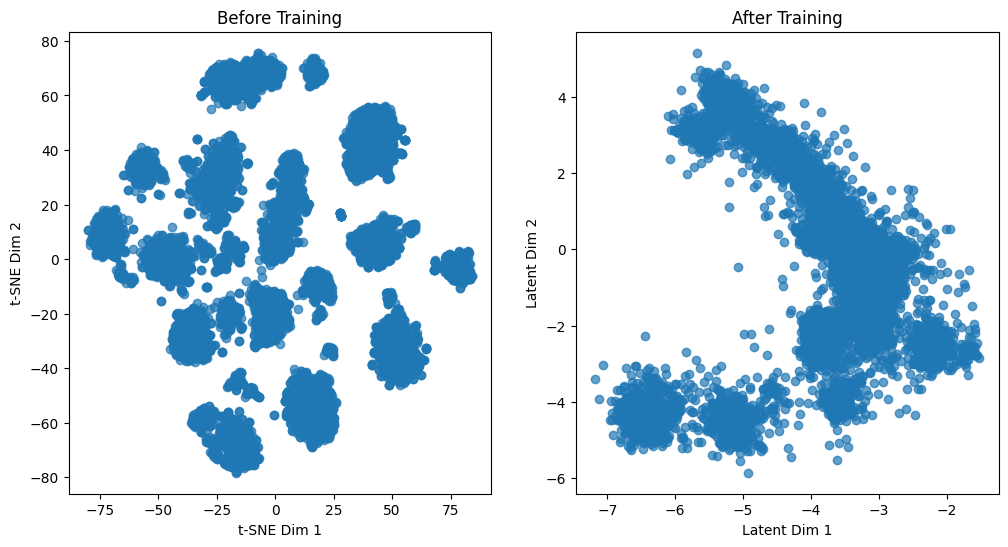

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Simulated normalized signals
#normalized_signals = np.random.rand(1000, 50)  # Replace with your actual `normalized_signals`

# Define Gradient Reversal Layer
class GradientReversal(layers.Layer):
    def __init__(self, lambda_):
        super(GradientReversal, self).__init__()
        self.lambda_ = lambda_

    def call(self, x, training=None):
        @tf.custom_gradient
        def grad_reversal(x):
            def custom_grad(dy):
                return -self.lambda_ * dy
            return x, custom_grad
        return grad_reversal(x)

# Define Encoder
def build_encoder(input_dim, latent_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(latent_dim, activation=None)  # Linear latent space
    ], name="encoder")
    return model

# Define Domain Discriminator
def build_domain_discriminator(latent_dim):
    model = models.Sequential([
        layers.Input(shape=(latent_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid')  # Domain classification
    ], name="domain_discriminator")
    return model

# Contrastive Loss
class ContrastiveLoss(tf.keras.losses.Loss):
    def __init__(self, temperature=0.1):
        super(ContrastiveLoss, self).__init__()
        self.temperature = temperature

    def call(self, z_i, z_j):
        # Normalize embeddings
        z_i = tf.math.l2_normalize(z_i, axis=1)
        z_j = tf.math.l2_normalize(z_j, axis=1)

        # Compute similarity
        similarity = tf.matmul(z_i, z_j, transpose_b=True)
        logits = similarity / self.temperature
        labels = tf.range(tf.shape(z_i)[0])
        return tf.reduce_mean(tf.nn.sparse_softmax_cross_entropy_with_logits(labels, logits))

# Pair Generation for Contrastive Loss
def create_pairs(data):
    n = data.shape[0]
    idxs = np.arange(n)
    np.random.shuffle(idxs)
    positive_pairs = [(data[i], data[(i + 1) % n]) for i in idxs]
    return positive_pairs

# Build Networks
input_dim = normalized_signals.shape[1]
latent_dim = 2  # For visualization

encoder = build_encoder(input_dim, latent_dim)
domain_discriminator = build_domain_discriminator(latent_dim)

# Optimizers
encoder_optimizer = optimizers.Adam(learning_rate=0.001)
domain_discriminator_optimizer = optimizers.Adam(learning_rate=0.001)

# Losses
domain_loss_fn = tf.keras.losses.BinaryCrossentropy()
contrastive_loss_fn = ContrastiveLoss(temperature=0.1)

# Training Loop
batch_size = 32
num_epochs = 20
lambda_ = 0.1  # Trade-off for domain loss

dataset = tf.data.Dataset.from_tensor_slices(normalized_signals).batch(batch_size)

for epoch in range(num_epochs):
    total_domain_loss = 0
    total_contrastive_loss = 0

    for batch_data in dataset:
        # Generate pseudo domain labels (random split for unsupervised setting)
        batch_size = batch_data.shape[0]
        pseudo_labels = tf.cast(tf.random.uniform([batch_size, 1]) > 0.5, tf.float32)

        # Create positive pairs for contrastive loss
        positive_pairs = create_pairs(batch_data.numpy())
        z_i = np.array([p[0] for p in positive_pairs])
        z_j = np.array([p[1] for p in positive_pairs])

        with tf.GradientTape(persistent=True) as tape:
            # Forward pass
            latent_z = encoder(batch_data, training=True)
            reversed_z = GradientReversal(lambda_)(latent_z)
            domain_predictions = domain_discriminator(reversed_z)

            # Compute losses
            domain_loss = domain_loss_fn(pseudo_labels, domain_predictions)
            contrastive_loss = contrastive_loss_fn(encoder(z_i, training=True), encoder(z_j, training=True))

            total_loss = contrastive_loss + lambda_ * domain_loss

        # Backward pass
        # Update encoder
        encoder_gradients = tape.gradient(total_loss, encoder.trainable_variables)
        encoder_optimizer.apply_gradients(zip(encoder_gradients, encoder.trainable_variables))

        # Update domain discriminator
        discriminator_gradients = tape.gradient(domain_loss, domain_discriminator.trainable_variables)
        domain_discriminator_optimizer.apply_gradients(zip(discriminator_gradients, domain_discriminator.trainable_variables))

        total_domain_loss += domain_loss.numpy()
        total_contrastive_loss += contrastive_loss.numpy()

    print(f"Epoch {epoch + 1}/{num_epochs}, Domain Loss: {total_domain_loss:.4f}, Contrastive Loss: {total_contrastive_loss:.4f}")

# Visualize Latent Space Before and After Training
# t-SNE before training
tsne_before = TSNE(n_components=2).fit_transform(normalized_signals)

# Latent space after training
encoded_after = encoder.predict(normalized_signals)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].scatter(tsne_before[:, 0], tsne_before[:, 1], alpha=0.7, cmap='viridis')
axes[0].set_title("Before Training")
axes[0].set_xlabel("t-SNE Dim 1")
axes[0].set_ylabel("t-SNE Dim 2")

axes[1].scatter(encoded_after[:, 0], encoded_after[:, 1], alpha=0.7, cmap='viridis')
axes[1].set_title("After Training")
axes[1].set_xlabel("Latent Dim 1")
axes[1].set_ylabel("Latent Dim 2")

plt.show()


# Encoder

In [ ]:
# Assuming normalized_signals is your dataset
data = np.array(normalized_signals)  # Make sure your dataset is a NumPy array
input_dim = data.shape[1]
# Define the input layer
input_layer = Input(shape=(input_dim,))

# Encoder: Reduce to 2D latent space
encoded = Dense(256, activation='relu')(input_layer)
encoded = Dense(128, activation='relu')(encoded)
encoded = Dense(32, activation='relu')(encoded)
encoded = Dense(8, activation='linear')(encoded)
#encoded = Lambda(lambda x: tf.math.log(tf.nn.softplus(0.01*x)))(encoded)
#encoded = Lambda(lambda x: tf.math.log(x+12))(encoded)

decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

# Autoencoder model
autoencoder = Model(input_layer, decoded)
encoder = Model(input_layer, encoded)

# Compile the model
autoencoder.compile(optimizer=Adam(), loss='mse')
# Train the autoencoder
autoencoder.fit(data, data, epochs=40, batch_size=256, shuffle=True)
# Encode the data into 2D space
encoded_data = encoder.predict(data)

Epoch 1/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - loss: 0.0323
Epoch 2/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0054
Epoch 3/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0029
Epoch 4/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0022
Epoch 5/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0021
Epoch 6/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0020
Epoch 7/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0019
Epoch 8/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0018
Epoch 9/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0017
Epoch 10/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0016
Epoch 11/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0017
Epoch 12/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0016
Epoch 13/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0015
Epoch 14/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0015
Epoch 15/40
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0014
Epoch 16/40
97/97

<ipython-input-19-ee9eb546c2c5>:9: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  scatter = plt.scatter(encoded_data[:, 0], encoded_data[:, 1], c=carb_targets, cmap='viridis', alpha=0.7)
<ipython-input-19-ee9eb546c2c5>:10: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.colorbar(scatter, label='Carb Values')  # Add colorbar to indicate carb values


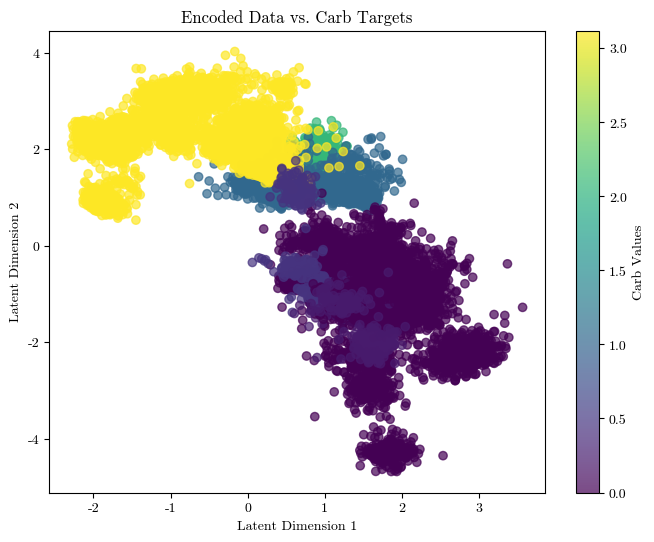

In [ ]:
#encoded_data = encoded_after[:,0]

# Assuming `encoded_after` contains the 2D latent space representations
# and `carb_targets` is a NumPy array of the same length as `normalized_signals`
carb_targets = targets[:, 1]

# Plot the encoded data with carb values
plt.figure(figsize=(8, 6))
scatter = plt.scatter(encoded_data[:, 0], encoded_data[:, 1], c=carb_targets, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='Carb Values')  # Add colorbar to indicate carb values
plt.title("Encoded Data vs. Carb Targets")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.show()



<ipython-input-90-24a0a7d9371a>:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('nipy_spectral', len(unique_classes))
<ipython-input-90-24a0a7d9371a>:21: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.scatter(


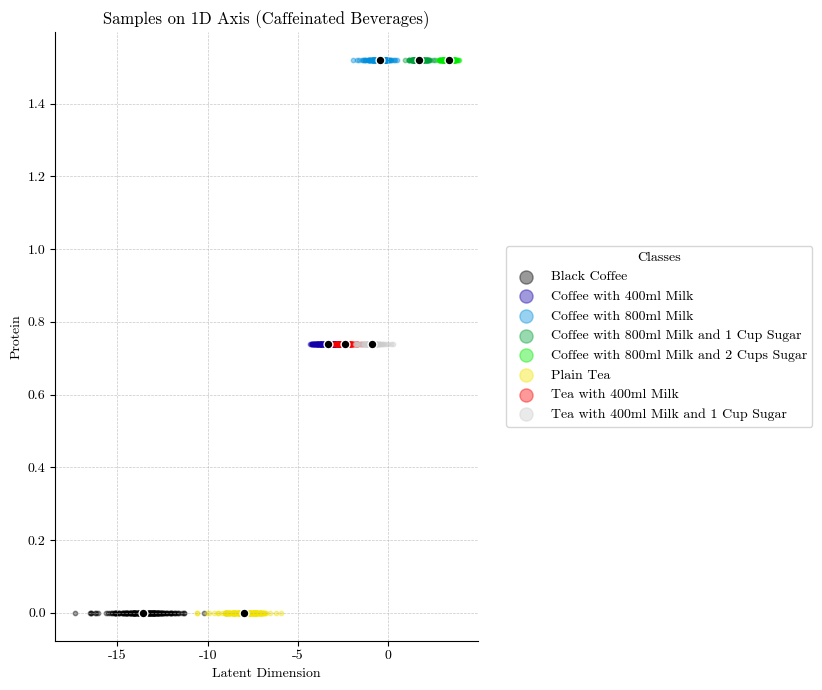

In [ ]:
# Assuming all imports and data setup are done
import numpy as np
import matplotlib.pyplot as plt

carb_targets = targets[:, 2]
unique_classes = np.unique(class_names)

# Plotting the 1D encoded data
plt.figure(figsize=(10, 7))

# Use the 'nipy_spectral' colormap to get a wide range of distinct colors
colors = plt.cm.get_cmap('nipy_spectral', len(unique_classes))

for idx, class_name in enumerate(unique_classes):
    indices = np.where(class_names == class_name)
    formal_name = formal_mapping.get(class_name, class_name)  # Default to `cls` if no mapping exists

    class_data = encoded_data[indices]

    # Plot the scatter points along the 1D axis with distinct colors from the colormap
    plt.scatter(
        class_data[:, 0],
        carb_targets[indices],
        label=formal_name,
        color=colors(idx / len(unique_classes)),
        s=10,  # Size of the data points
        alpha=0.4  # Opacity of the data points
    )

    # Calculate the centroid of the cluster
    centroid_x = np.mean(class_data[:, 0])
    centroid_y = np.mean(carb_targets[indices])

    # Plot a round dot at the centroid
    plt.scatter(centroid_x, centroid_y, color='black', s=40, edgecolor='white', zorder=5)

plt.title('Samples on 1D Axis (Caffeinated Beverages)')
plt.xlabel('Latent Dimension')
plt.ylabel('Protein')

# Remove all boundaries
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Move the legend outside the plot
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), ncol=1, title="Classes", scatterpoints=1, markerscale=3)
plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust layout to make room for the legend

plt.savefig('Caffeinated_Beverages_encoder.png', dpi=300, bbox_inches='tight')


# Final Code

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Apply the class mapping
categories = [category_mapping[class_name] for class_name in class_names]

# Encode the categories into numerical labels
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(categories)
labels_one_hot = to_categorical(labels)  # One-hot encode the labels for CNN

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets using train_test_split
train_mask, test_mask = train_test_split(np.arange(len(normalized_signals)), test_size=0.2, random_state=42)

# Classification data split
X_train = normalized_signals[train_mask]
X_test = normalized_signals[test_mask]
y_train = labels[train_mask]
y_test = labels[test_mask]
class_names_train = np.array(class_names)[train_mask]
class_names_test = np.array(class_names)[test_mask]
labels_train_one_hot = labels_one_hot[train_mask]
labels_test_one_hot = labels_one_hot[test_mask]

# Normalize input data
row_means = np.mean(X_train, axis=1, keepdims=True)
X_train = X_train - row_means
row_means = np.mean(X_test, axis=1, keepdims=True)
X_test = X_test - row_means

# Reshape the input data for 1D CNN (samples, time_steps, features)
X_train_cnn = X_train[..., np.newaxis]
X_test_cnn = X_test[..., np.newaxis]

In [ ]:
# Step 1: Initialize the Deep CNN model
model = Sequential()
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(filters=256, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))  # Prevent overfitting
model.add(Dense(64, activation='relu'))
model.add(Dense(len(label_encoder.classes_), activation='softmax'))  # Output layer for classification

# Step 2: Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Step 3: Train the Deep CNN model and capture the training history
history = model.fit(X_train_cnn, labels_train_one_hot, epochs=20, batch_size=32, verbose=1, validation_split=0.2)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
496/496 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8678 - loss: 0.3211 - val_accuracy: 0.9768 - val_loss: 0.0671
Epoch 2/20
496/496 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9744 - loss: 0.0733 - val_accuracy: 0.9889 - val_loss: 0.0372
Epoch 3/20
496/496 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9841 - loss: 0.0450 - val_accuracy: 0.9909 - val_loss: 0.0269
Epoch 4/20
496/496 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9876 - loss: 0.0345 - val_accuracy: 0.9945 - val_loss: 0.0178
Epoch 5/20
496/496 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9882 - loss: 0.0307 - val_accuracy: 0.9937 - val_loss: 0.0264
Epoch 6/20
496/496 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9924 - loss: 0.0246 - val_accuracy: 0.9937 - val_loss: 0.0226
Epoch 7/20
496/496 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9938 - loss: 0.0183 - val_accuracy: 0.9914 - val_loss: 0.0307
Epoch 8/20
496/496 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9920 - loss: 0.0214 - val_accuracy: 0.

39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
Deep CNN - Accuracy: 0.9968

Classification Report:

                       precision    recall  f1-score   support

Caffeinated Beverages       1.00      1.00      1.00        79
 Carbonated Beverages       0.99      1.00      0.99       328
Dairy-Based Beverages       1.00      1.00      1.00       550
  Hydration Beverages       1.00      0.99      0.99       283

             accuracy                           1.00      1240
            macro avg       1.00      1.00      1.00      1240
         weighted avg       1.00      1.00      1.00      1240



/usr/local/lib/python3.11/dist-packages/seaborn/matrix.py:456: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  ax = plt.gca()
/usr/local/lib/python3.11/dist-packages/seaborn/matrix.py:316: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  cb = ax.figure.colorbar(mesh, cax, ax, **self.cbar_kws)


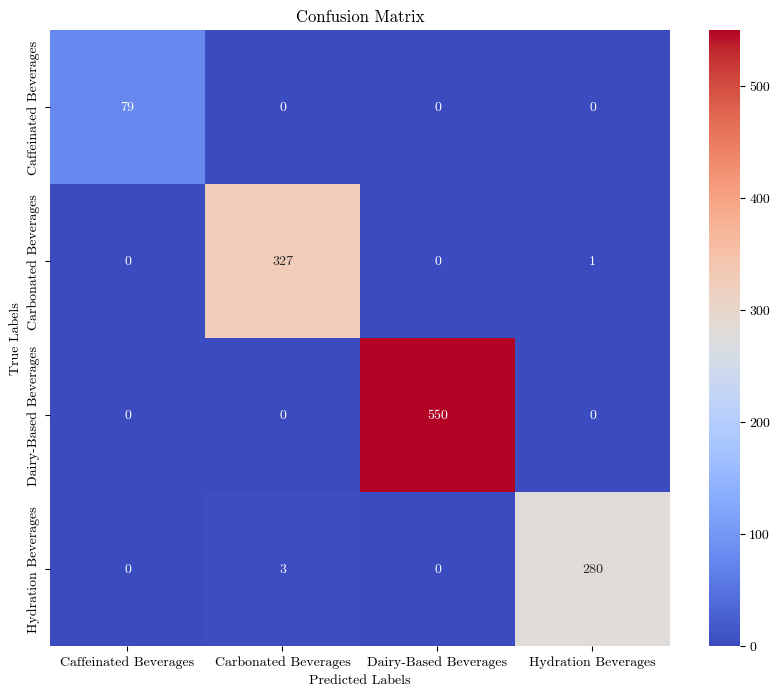

In [ ]:
# Step 4: Make predictions using the trained model
y_pred_cnn = model.predict(X_test_cnn)
y_pred_labels = np.argmax(y_pred_cnn, axis=1)
y_true_labels = np.argmax(labels_test_one_hot, axis=1)

# Step 5: Calculate Accuracy for CNN predictions
accuracy_cnn = accuracy_score(y_true_labels, y_pred_labels)
print(f'Deep CNN - Accuracy: {accuracy_cnn:.4f}')

# Step 6: Generate and Display Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true_labels, y_pred_labels, target_names=label_encoder.classes_))

# Step 7: Confusion Matrix Visualization
conf_matrix = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='coolwarm', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:2351: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  ax = plt.gca()


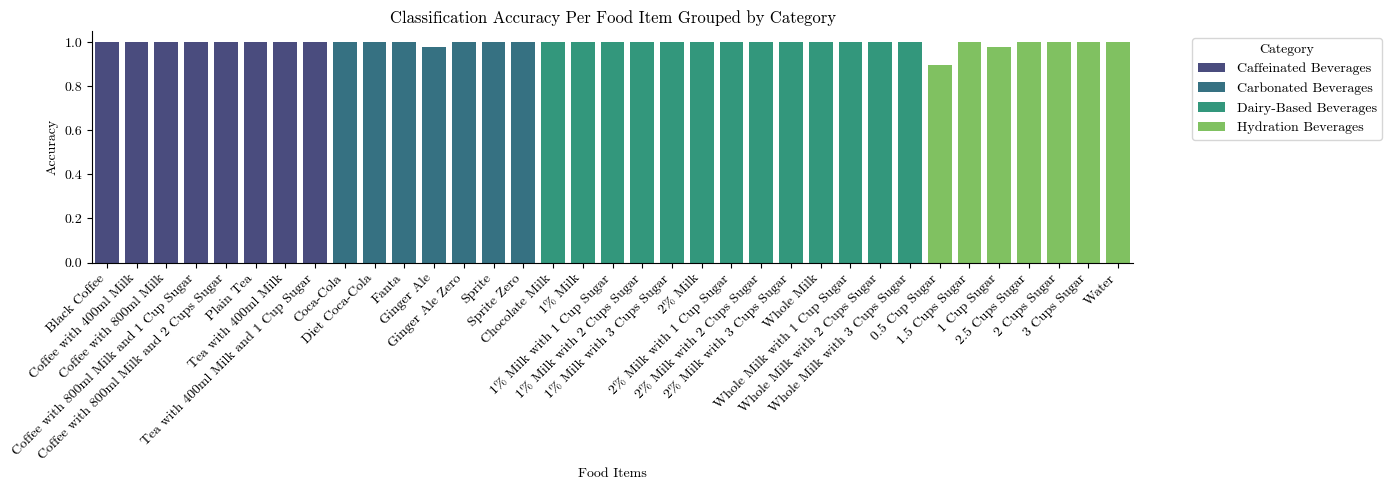

In [ ]:
# Step 8: Classification Accuracy for Each Food Item Grouped by Category
accuracy_per_food = pd.DataFrame({'Food Item': class_names_test, 'Category': [category_mapping[item] for item in class_names_test], 'Correct': y_true_labels == y_pred_labels})
accuracy_summary = accuracy_per_food.groupby(['Category', 'Food Item'])['Correct'].mean().reset_index()
accuracy_summary = accuracy_summary.sort_values(by=['Category', 'Food Item'])

# Improved plot with seaborn aesthetics
plt.figure(figsize=(14, 5))
sns.barplot(data=accuracy_summary, x='Food Item', y='Correct', hue='Category', dodge=False, palette='viridis')
plt.xlabel('Food Items')
plt.ylabel('Accuracy')
plt.title('Classification Accuracy Per Food Item Grouped by Category')

# Improved x-axis label rotation and alignment
plt.xticks(
    ticks=range(len(accuracy_summary['Food Item'])),
    labels=[formal_mapping[item] for item in accuracy_summary['Food Item']],
    rotation=45,  # Change to 45 degrees for better readability
    ha='right',   # Align the labels to the right
    fontsize=10
)

plt.yticks(fontsize=10)
sns.despine()
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('classification_accuracy_seen.png', dpi=300, bbox_inches='tight')

In [ ]:
from sklearn.metrics import mean_squared_error, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Regression data split #CFP
carb_targets = targets[:, 0]  # Assuming carbs are the first element in the target array
X_train_reg = encoded_data[train_mask]
X_test_reg = encoded_data[test_mask]
y_train_reg = carb_targets[train_mask]
y_test_reg = carb_targets[test_mask]

# Step 2: Get class probabilities for X_test
class_probabilities = model.predict(X_test_cnn)  # Shape: (n_samples, n_classes)

# Step 3: Train SVR regressors for each class based on carb targets
unique_classes = np.unique(y_train)  # Find unique categories (e.g., Coffee, Soda, etc.)
regressors = {}

# Fit SVRs on X_train_reg to predict y_train_reg for each category
for category in unique_classes:
    mask = (y_train == category)
    regressor = SVR(kernel='rbf', C=100, gamma='scale')  # Initialize SVR regressor
    regressor.fit(X_train_reg[mask], y_train_reg[mask])
    regressors[category] = regressor

# Step 4: Predict carb values using the regressor for the detected category
carb_predictions = np.zeros(len(X_test_reg))
predicted_classes = np.argmax(class_probabilities, axis=1)

for i in range(len(X_test_reg)):
    category = predicted_classes[i]  # Get the detected category for each sample
    carb_predictions[i] = regressors[category].predict([X_test_reg[i]])[0]  # Predict using the category-specific SVR
    if i % 100 == 0:  # Print progress every 100 samples
        print(f"Progress: {100 * i / len(X_test_reg):.2f}%")


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Progress: 0.00%
Progress: 2.02%
Progress: 4.03%
Progress: 6.05%
Progress: 8.06%
Progress: 10.08%
Progress: 12.10%
Progress: 14.11%
Progress: 16.13%
Progress: 18.15%
Progress: 20.16%
Progress: 22.18%
Progress: 24.19%
Progress: 26.21%
Progress: 28.23%
Progress: 30.24%
Progress: 32.26%
Progress: 34.27%
Progress: 36.29%
Progress: 38.31%
Progress: 40.32%
Progress: 42.34%
Progress: 44.35%
Progress: 46.37%
Progress: 48.39%
Progress: 50.40%
Progress: 52.42%
Progress: 54.44%
Progress: 56.45%
Progress: 58.47%
Progress: 60.48%
Progress: 62.50%
Progress: 64.52%
Progress: 66.53%
Progress: 68.55%
Progress: 70.56%
Progress: 72.58%
Progress: 74.60%
Progress: 76.61%
Progress: 78.63%
Progress: 80.65%
Progress: 82.66%
Progress: 84.68%
Progress: 86.69%
Progress: 88.71%
Progress: 90.73%
Progress: 92.74%
Progress: 94.76%
Progress: 96.77%
Progress: 98.79%


Mean Squared Error for Fat Predictions: 0.0025521888214922856
Mean Absolute Error for Fat Predictions: 0.023412843578703643
Overall Classification Accuracy: 99.76%

Mean Absolute Error and Standard Deviation per Food Item:
                         Food Item       MAE    StdDev
0                       Coffee_8sp  0.050893  0.064898
1              Coffee_8sp_Milk_400  0.072392  0.114658
2              Coffee_8sp_Milk_800  0.105106  0.106903
3   Coffee_8sp_Milk_800_Sugar_1Cup  0.064854  0.061158
4   Coffee_8sp_Milk_800_Sugar_2Cup  0.034001  0.032337
5                             Coke  0.000000  0.000000
6                         DietCoke  0.000000  0.000000
7                            Fanta  0.000000  0.000000
8                           Ginger  0.000000  0.000000
9                       GingerZero  0.000000  0.000000
10                          Sprite  0.006115  0.084505
11                      SpriteZero  0.000000  0.000000
12                    Sugar_0.5Cup  0.000000  0.000000
13     

/usr/local/lib/python3.11/dist-packages/seaborn/distributions.py:1677: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  ax = plt.gca()


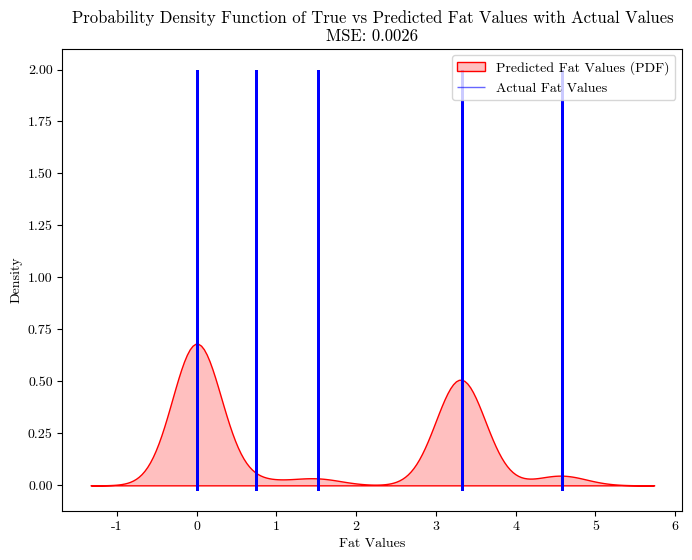

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score

# Step 5: Evaluate
mse = mean_squared_error(y_test_reg, carb_predictions)
mae = mean_absolute_error(y_test_reg, carb_predictions)
print(f"Mean Squared Error for Fat Predictions: {mse}")
print(f"Mean Absolute Error for Fat Predictions: {mae}")

# Step 6: Classification accuracy
overall_accuracy = accuracy_score(y_test, predicted_classes)
print(f"Overall Classification Accuracy: {overall_accuracy * 100:.2f}%")

# Step 7: Calculate and display MAE and standard deviation per food item
results_df = pd.DataFrame({
    'Food Item': np.array(class_names_test),
    'True Fat Value': y_test_reg,
    'Predicted Fat Value': carb_predictions
})

results_df['Absolute Error'] = abs(results_df['True Fat Value'] - results_df['Predicted Fat Value'])
summary_stats = results_df.groupby('Food Item').agg(
    MAE=('Absolute Error', 'mean'),
    StdDev=('Absolute Error', 'std')
).reset_index()

print("\nMean Absolute Error and Standard Deviation per Food Item:")
print(summary_stats)

# Step 8: Visualize the regression results
plt.figure(figsize=(8, 6))
sns.kdeplot(carb_predictions, label='Predicted Fat Values (PDF)', color='red', fill=True)
plt.vlines(y_test_reg, ymin=-0.02, ymax=2, color='blue', alpha=0.6, linewidth=1, label='Actual Fat Values')
plt.title(f'Probability Density Function of True vs Predicted Fat Values with Actual Values\nMSE: {mse:.4f}')
plt.xlabel('Fat Values')
plt.ylabel('Density')
plt.legend()
plt.show()

# Unseen

In [ ]:
unique = np.unique(class_names)

In [ ]:
unique

array(['Coffee_8sp', 'Coffee_8sp_Milk_400', 'Coffee_8sp_Milk_800',
       'Coffee_8sp_Milk_800_Sugar_1Cup', 'Coffee_8sp_Milk_800_Sugar_2Cup',
       'Coke', 'DietCoke', 'Fanta', 'Ginger', 'GingerZero', 'Sprite',
       'SpriteZero', 'Sugar_0.5Cup', 'Sugar_1.5Cup', 'Sugar_1Cup',
       'Sugar_2.5Cup', 'Sugar_2Cup', 'Sugar_3Cup', 'Tea_6Bags',
       'Tea_6Bags_Milk_400', 'Tea_6Bags_Milk_400_Sugar_1Cup', 'Water',
       'chocolate_milk', 'milk_1', 'milk_1_Sugar_1Cup',
       'milk_1_Sugar_2Cup', 'milk_1_Sugar_3Cup', 'milk_2',
       'milk_2_Sugar_1Cup', 'milk_2_Sugar_2Cup', 'milk_2_Sugar_3Cup',
       'milk_3', 'milk_3_Sugar_1Cup', 'milk_3_Sugar_2Cup',
       'milk_3_Sugar_3Cup'], dtype='<U30')

In [ ]:
from sklearn.svm import SVR
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Loop through each food item to evaluate model performance
#unique = np.unique(class_names)
#unique = unique[18:34]
unique = ['Coffee_8sp_Milk_400']
# Store predictions and regression performance for each food item
predicted_categories = []
overall_accuracies = []
regression_results = {"carb": [], "fat": [], "protein": []}

# Loop through each food item to evaluate model performance
for test_item in unique:
    print(f"Evaluating for test item: {test_item}")

    # Create masks for train and test sets
    test_mask = np.isin(class_names, [test_item])
    train_mask = ~test_mask

    # Classification data split
    X_train = normalized_signals[train_mask]
    X_test = normalized_signals[test_mask]
    y_train = labels[train_mask]
    y_test = labels[test_mask]
    class_names_train = np.array(class_names)[train_mask]
    class_names_test = np.array(class_names)[test_mask]
    labels_train_one_hot = labels_one_hot[train_mask]
    labels_test_one_hot = labels_one_hot[test_mask]

    # Normalize input data
    row_means = np.mean(X_train, axis=1, keepdims=True)
    X_train = X_train - row_means
    row_means = np.mean(X_test, axis=1, keepdims=True)
    X_test = X_test - row_means

    # Reshape the input data for 1D CNN (samples, time_steps, features)
    X_train_cnn = X_train[..., np.newaxis]
    X_test_cnn = X_test[..., np.newaxis]

    X_train_reg = encoded_data[train_mask]
    X_test_reg = encoded_data[test_mask]
    target_splits = {"carb": targets[:, 0], "fat": targets[:, 1], "protein": targets[:, 2]}


    # Step 1: Initialize the Deep CNN model
    model = Sequential()
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(filters=256, kernel_size=3, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(len(np.unique(labels)), activation='softmax'))

    # Step 2: Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

    # Step 3: Train the Deep CNN model
    model.fit(X_train_cnn, labels_train_one_hot, epochs=2, batch_size=32, verbose=0, validation_data=(X_test_cnn, labels_test_one_hot))

    # Step 4: Evaluate model performance
    y_pred_cnn = model.predict(X_test_cnn)
    y_pred_labels = np.argmax(y_pred_cnn, axis=1)
    y_true_labels = np.argmax(labels_test_one_hot, axis=1)

    # Store predicted category
    predicted_categories.append((test_item, class_names_test[0], y_pred_labels[0]))

    # Calculate accuracy
    overall_accuracy = accuracy_score(y_true_labels, y_pred_labels)
    overall_accuracies.append(overall_accuracy)
    print(f"Overall Classification Accuracy for {test_item}: {overall_accuracy * 100:.2f}%")

    # Regression data split
    carb_targets = targets[:, 0]  # Assuming carbs are the first element in the target array

    y_train_reg = carb_targets[train_mask]
    y_test_reg = carb_targets[test_mask]

    # Regression step
    class_probabilities = model.predict(X_test_cnn)
    unique_classes = np.unique(y_train)

    for target_type in target_splits:
        y_train_reg = target_splits[target_type][train_mask]
        y_test_reg = target_splits[target_type][test_mask]

        # Train regressors
        regressors = {}
        for category in unique_classes:
            mask = (y_train == category)
            regressor = SVR(kernel='rbf', C=100, gamma='scale')
            regressor.fit(X_train_reg[mask], y_train_reg[mask])
            regressors[category] = regressor

        # Predict regression values
        predictions = np.zeros(len(X_test_reg))
        predicted_classes = np.argmax(class_probabilities, axis=1)
        for i in range(len(X_test_reg)):
            category = predicted_classes[i]
            predictions[i] = regressors[category].predict([X_test_reg[i]])[0]

        # Evaluate regression performance
        mae = mean_absolute_error(y_test_reg, predictions)
        std_dev = np.std(predictions - y_test_reg)
        regression_results[target_type].append({'Food Item': test_item, 'MAE': mae, 'StdDev': std_dev})
        print(f"{target_type.capitalize()} MAE for {test_item}: {mae}")
        print(f"{target_type.capitalize()} StdDev for {test_item}: {std_dev}")



Evaluating for test item: Coffee_8sp_Milk_400


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 234ms/step
Overall Classification Accuracy for Coffee_8sp_Milk_400: 96.50%
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 328ms/step
Carb MAE for Coffee_8sp_Milk_400: 0.29114331003448835
Carb StdDev for Coffee_8sp_Milk_400: 0.3601242500389755
Fat MAE for Coffee_8sp_Milk_400: 0.03143828829645965
Fat StdDev for Coffee_8sp_Milk_400: 0.042882474573883986
Protein MAE for Coffee_8sp_Milk_400: 0.3525142205094107
Protein StdDev for Coffee_8sp_Milk_400: 0.16000678118276376


/usr/local/lib/python3.11/dist-packages/seaborn/distributions.py:1677: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  ax = plt.gca()


(array([-0.5,  0. ,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ]),
 [Text(0, -0.5, '-0.5'),
  Text(0, 0.0, '0.0'),
  Text(0, 0.5, '0.5'),
  Text(0, 1.0, '1.0'),
  Text(0, 1.5, '1.5'),
  Text(0, 2.0, '2.0'),
  Text(0, 2.5, '2.5'),
  Text(0, 3.0, '3.0')])

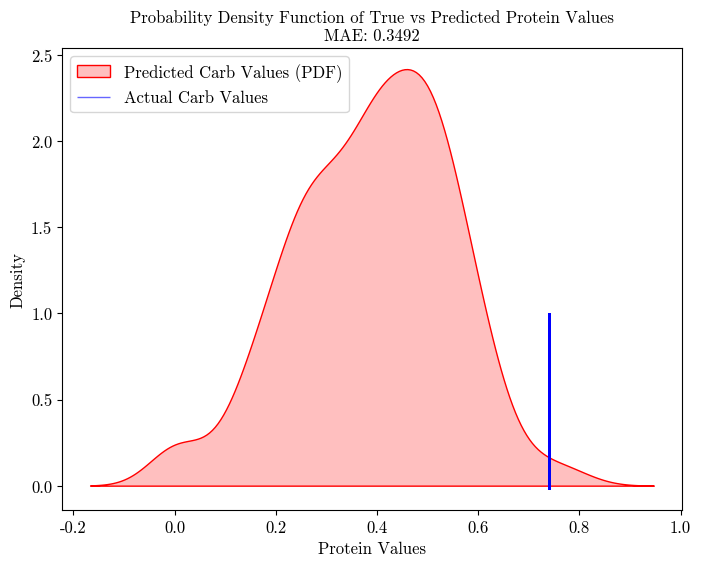

In [ ]:
# Step 7: Visualize the regression results using PDF
plt.figure(figsize=(8, 6))
# Plot the PDF of the predicted carb values (carb_predictions)
sns.kdeplot(predictions, label='Predicted Carb Values (PDF)', color='red', fill=True)
# Overlay the actual carb values as longer vertical lines
plt.vlines(y_test_reg, ymin=-0.02, ymax=1, color='blue', alpha=0.6, linewidth=1, label='Actual Carb Values')
# Add labels and title
plt.title(f'Probability Density Function of True vs Predicted {target_type.capitalize()} Values\nMAE: {mae:.4f}', fontsize=12)
plt.xlabel(f'{target_type.capitalize()} Values', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

array(['Coffee_8sp', 'Coffee_8sp_Milk_400', 'Coffee_8sp_Milk_800',
       'Coffee_8sp_Milk_800_Sugar_1Cup', 'Coffee_8sp_Milk_800_Sugar_2Cup',
       'Coke', 'DietCoke', 'Fanta', 'Ginger', 'GingerZero', 'Sprite',
       'SpriteZero', 'Sugar_0.5Cup', 'Sugar_1.5Cup', 'Sugar_1Cup',
       'Sugar_2.5Cup', 'Sugar_2Cup', 'Sugar_3Cup', 'Tea_6Bags',
       'Tea_6Bags_Milk_400', 'Tea_6Bags_Milk_400_Sugar_1Cup', 'Water',
       'chocolate_milk', 'milk_1', 'milk_1_Sugar_1Cup',
       'milk_1_Sugar_2Cup', 'milk_1_Sugar_3Cup', 'milk_2',
       'milk_2_Sugar_1Cup', 'milk_2_Sugar_2Cup', 'milk_2_Sugar_3Cup',
       'milk_3', 'milk_3_Sugar_1Cup', 'milk_3_Sugar_2Cup',
       'milk_3_Sugar_3Cup'], dtype='<U30')

Evaluating for test item: Coffee_8sp_Milk_400


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
Overall Classification Accuracy for Coffee_8sp_Milk_400: 99.00%
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Carb MAE for Coffee_8sp_Milk_400: 0.27273800361302086
Carb StdDev for Coffee_8sp_Milk_400: 0.3325546294526002


/usr/local/lib/python3.11/dist-packages/seaborn/distributions.py:1677: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  ax = plt.gca()


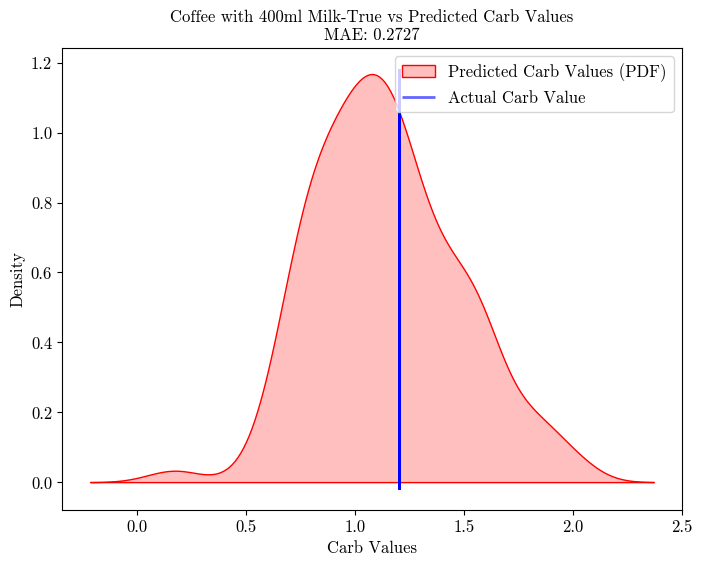

Fat MAE for Coffee_8sp_Milk_400: 0.026872862759366834
Fat StdDev for Coffee_8sp_Milk_400: 0.02851000909360723


/usr/local/lib/python3.11/dist-packages/seaborn/distributions.py:1677: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  ax = plt.gca()


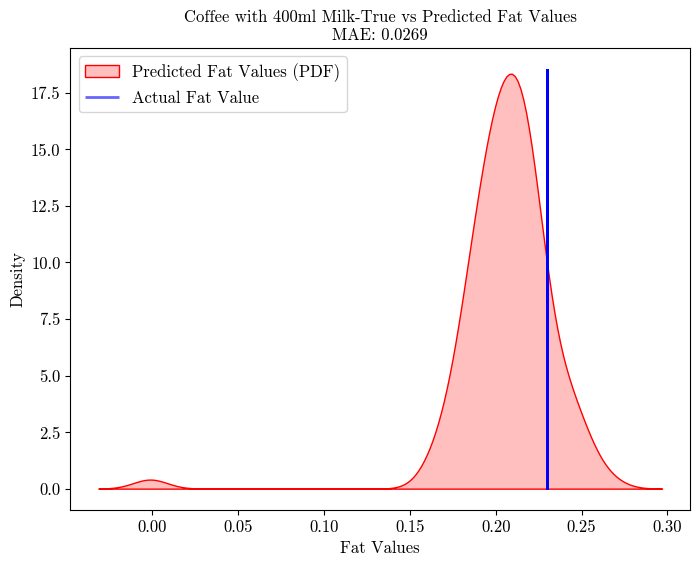

Protein MAE for Coffee_8sp_Milk_400: 0.3483967367663204
Protein StdDev for Coffee_8sp_Milk_400: 0.15229765981413915


/usr/local/lib/python3.11/dist-packages/seaborn/distributions.py:1677: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  ax = plt.gca()


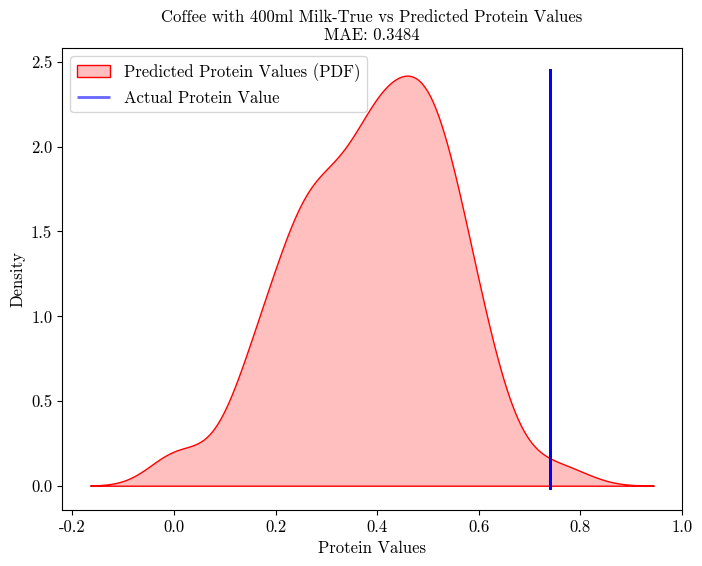

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Assuming necessary data is already loaded and preprocessed
unique = ['Coffee_8sp_Milk_400']
predicted_categories = []
overall_accuracies = []
regression_results = {"carb": [], "fat": [], "protein": []}
target_splits = {"carb": targets[:, 0], "fat": targets[:, 1], "protein": targets[:, 2]}

for test_item in unique:
    print(f"Evaluating for test item: {test_item}")

    # Create masks for train and test sets
    test_mask = np.isin(class_names, [test_item])
    train_mask = ~test_mask

    # Classification data split
    X_train = normalized_signals[train_mask]
    X_test = normalized_signals[test_mask]
    y_train = labels[train_mask]
    y_test = labels[test_mask]
    labels_train_one_hot = labels_one_hot[train_mask]
    labels_test_one_hot = labels_one_hot[test_mask]

    # Normalize input data
    row_means = np.mean(X_train, axis=1, keepdims=True)
    X_train = X_train - row_means
    row_means = np.mean(X_test, axis=1, keepdims=True)
    X_test = X_test - row_means

    # Reshape the input data for 1D CNN (samples, time_steps, features)
    X_train_cnn = X_train[..., np.newaxis]
    X_test_cnn = X_test[..., np.newaxis]
    X_train_reg = encoded_data[train_mask]
    X_test_reg = encoded_data[test_mask]

    # Initialize the Deep CNN model
    model = Sequential()
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(filters=256, kernel_size=3, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(len(np.unique(labels)), activation='softmax'))

    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    model.fit(X_train_cnn, labels_train_one_hot, epochs=2, batch_size=32, verbose=0, validation_data=(X_test_cnn, labels_test_one_hot))

    # Evaluate model performance
    y_pred_cnn = model.predict(X_test_cnn)
    y_pred_labels = np.argmax(y_pred_cnn, axis=1)
    y_true_labels = np.argmax(labels_test_one_hot, axis=1)
    predicted_categories.append((test_item, class_names_test[0], y_pred_labels[0]))
    overall_accuracy = accuracy_score(y_true_labels, y_pred_labels)
    overall_accuracies.append(overall_accuracy)
    print(f"Overall Classification Accuracy for {test_item}: {overall_accuracy * 100:.2f}%")

    # Regression data split
    class_probabilities = model.predict(X_test_cnn)
    unique_classes = np.unique(y_train)

    for target_type in target_splits:
        y_train_reg = target_splits[target_type][train_mask]
        y_test_reg = target_splits[target_type][test_mask]

        regressors = {}
        for category in unique_classes:
            mask = (y_train == category)
            regressor = SVR(kernel='rbf', C=100, gamma='scale')
            regressor.fit(X_train_reg[mask], y_train_reg[mask])
            regressors[category] = regressor

        predictions = np.zeros(len(X_test_reg))
        predicted_classes = np.argmax(class_probabilities, axis=1)
        for i in range(len(X_test_reg)):
            category = predicted_classes[i]
            predictions[i] = regressors[category].predict([X_test_reg[i]])[0]

        mae = mean_absolute_error(y_test_reg, predictions)
        std_dev = np.std(predictions - y_test_reg)
        regression_results[target_type].append({'Food Item': test_item, 'MAE': mae, 'StdDev': std_dev})
        print(f"{target_type.capitalize()} MAE for {test_item}: {mae}")
        print(f"{target_type.capitalize()} StdDev for {test_item}: {std_dev}")

        # Step 7: Visualize the regression results using PDF
        plt.figure(figsize=(8, 6))


        # Get the maximum y value of the KDE plot
        predictions += np.random.normal(0, 1e-3, predictions.shape)  # Adding small noise to avoid singular matrix
        kde = gaussian_kde(predictions)
        x_values = np.linspace(min(predictions), max(predictions), 1000)
        y_values = kde(x_values)
        y_values_normalized = y_values / np.trapz(y_values, x_values)
        max_y_value = max(y_values_normalized)

        # Plot the PDF of the predicted carb values (carb_predictions)
        sns.kdeplot(predictions, label=f'Predicted {target_type.capitalize()} Values (PDF)', color='red', fill=True)
        # Overlay the actual carb values as longer vertical lines
        plt.vlines(y_test_reg, ymin=-0.02, ymax=max_y_value, color='blue', alpha=0.6, linewidth=2, label=f'Actual {target_type.capitalize()} Value')

        plt.title(f'Coffee with 400ml Milk-True vs Predicted {target_type.capitalize()} Values\nMAE: {mae:.4f}', fontsize=12)
        plt.xlabel(f'{target_type.capitalize()} Values', fontsize=12)
        plt.ylabel('Density', fontsize=12)
        plt.legend(fontsize=12)
        plt.xticks(fontsize=12)
        plt.yticks(fontsize=12)
        plt.savefig(f'{target_type}_Coffee_8sp_Milk_400.png', dpi=300, bbox_inches='tight')
        plt.show()


/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:2351: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  ax = plt.gca()


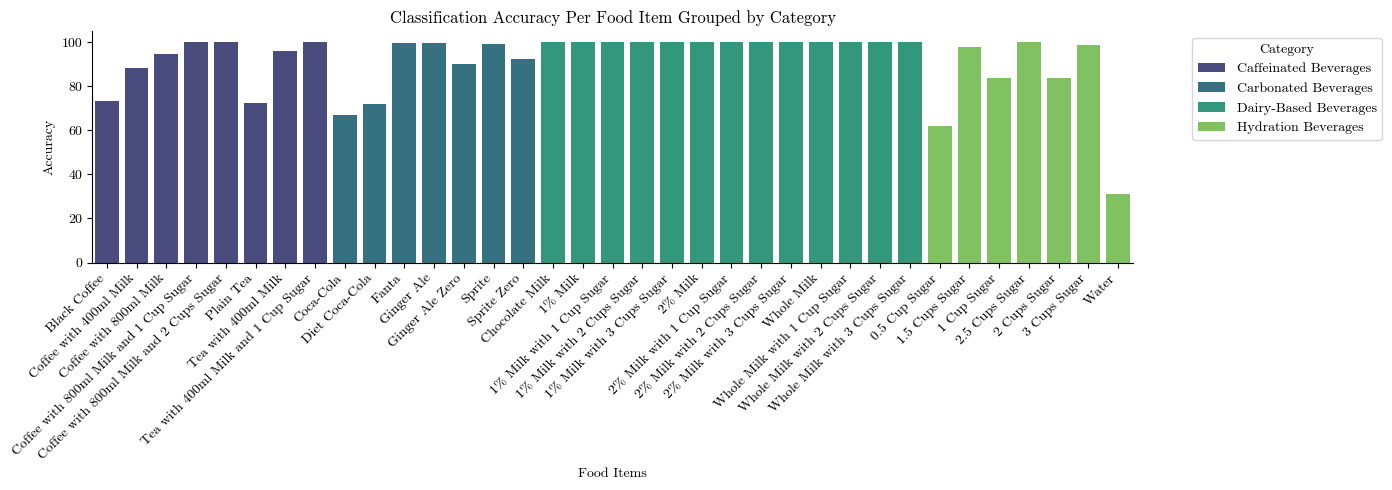

In [ ]:
data = {
    'Food Item': [
        'Coffee_8sp', 'Coffee_8sp_Milk_400', 'Coffee_8sp_Milk_800', 'Coffee_8sp_Milk_800_Sugar_1Cup',
        'Coffee_8sp_Milk_800_Sugar_2Cup', 'Coke', 'DietCoke', 'Fanta', 'Ginger', 'GingerZero', 'Sprite',
        'SpriteZero', 'Sugar_0.5Cup', 'Sugar_1.5Cup', 'Sugar_1Cup', 'Sugar_2.5Cup', 'Sugar_2Cup',
        'Sugar_3Cup', 'Tea_6Bags', 'Tea_6Bags_Milk_400', 'Tea_6Bags_Milk_400_Sugar_1Cup', 'Water',
        'chocolate_milk', 'milk_1', 'milk_1_Sugar_1Cup', 'milk_1_Sugar_2Cup', 'milk_1_Sugar_3Cup',
        'milk_2', 'milk_2_Sugar_1Cup', 'milk_2_Sugar_2Cup', 'milk_2_Sugar_3Cup', 'milk_3',
        'milk_3_Sugar_1Cup', 'milk_3_Sugar_2Cup', 'milk_3_Sugar_3Cup'
    ],
    'Accuracy': [
        73.50, 88.50, 94.74, 100.00, 100.00, 66.74, 71.82, 99.67, 99.46, 89.95, 99.33, 92.57, 61.95, 98.00, 83.70,
        100.00, 83.51, 98.80, 72.50, 95.94, 100.00, 31.08, 100.00, 99.90, 100.00, 100.00, 100.00, 99.88, 100.00,
        100.00, 100.00, 100.00, 100.00, 100.00, 100.00
    ],
        'Category': [category_mapping[item] for item in unique],  # map each food item to its category

}

# Creating a DataFrame
accuracy_per_food = pd.DataFrame(data)
# Group by Category and Food Item, and calculate the mean accuracy if needed
accuracy_summary = accuracy_per_food.groupby(['Category', 'Food Item'])['Accuracy'].mean().reset_index()

# Sorting the values by 'Category' and 'Food Item'
accuracy_summary = accuracy_summary.sort_values(by=['Category', 'Food Item'])
# Improved plot with seaborn aesthetics
plt.figure(figsize=(14, 5))
sns.barplot(data=accuracy_summary, x='Food Item', y='Accuracy', hue='Category', dodge=False, palette='viridis')
plt.xlabel('Food Items')
plt.ylabel('Accuracy')
plt.title('Classification Accuracy Per Food Item Grouped by Category')

# Improved x-axis label rotation and alignment
plt.xticks(
    ticks=range(len(accuracy_summary['Food Item'])),
    labels=[formal_mapping[item] for item in accuracy_summary['Food Item']],
    rotation=45,  # Change to 45 degrees for better readability
    ha='right',   # Align the labels to the right
    fontsize=10
)

plt.yticks(fontsize=10)
sns.despine()
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('classification_accuracy_unseen.png', dpi=300, bbox_inches='tight')

In [ ]:
np.size(data['Classification Accuracy (%)'])

36

# Old Codes

In [ ]:
# Apply the class mapping
categories = [category_mapping[class_name] for class_name in class_names]

# Encode the categories into numerical labels
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(categories)
labels_one_hot = to_categorical(labels)  # One-hot encode the labels for CNN

# Define the items for the test set
test_classes = ['milk_2_Sugar_2Cup']

# Create masks for train and test sets
test_mask = np.isin(class_names, test_classes)
train_mask = ~test_mask


In [ ]:
# Split the data into training and testing sets based on the masks
X_train = normalized_signals[train_mask]
X_test = normalized_signals[test_mask]
y_train = labels[train_mask]
y_test = labels[test_mask]

row_means = np.mean(X_train, axis=1, keepdims=True)
X_train = X_train - row_means
row_means = np.mean(X_test, axis=1, keepdims=True)
X_test = X_test - row_means

# Extract carbohydrate targets
carb_targets = targets[:, 0]  # Assuming carbs are the first element in the target array
X_train_reg = encoded_data[train_mask]
X_test_reg = encoded_data[test_mask]
y_train_reg = carb_targets[train_mask]
y_test_reg = carb_targets[test_mask]

Epoch 1/70


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 39.9878 - val_loss: 14.3742
Epoch 2/70
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.0597 - val_loss: 9.2463
Epoch 3/70
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0680 - val_loss: 8.9322
Epoch 4/70
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0392 - val_loss: 8.7645
Epoch 5/70
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0159 - val_loss: 8.6584
Epoch 6/70
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0215 - val_loss: 8.9671
Epoch 7/70
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0410 - val_loss: 8.6145
Epoch 8/70
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0798 - val_loss: 8.7689
Epoch 9/70
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0284 - val_loss: 8.8881
Epoch 10/70
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0033 - val_loss: 8.9995
Epoch 11/70
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0117 - val_loss: 8.8731
Epoch 12/70
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 

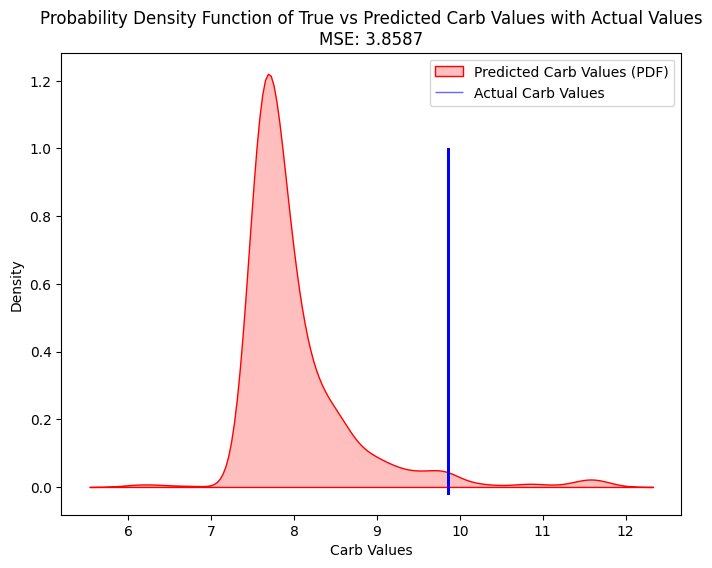

In [ ]:
# Step 1: Initialize the Neural Network model
model = Sequential()
model.add(Dense(64, input_dim=X_train_reg.shape[1], activation='relu'))  # Hidden layer with 64 neurons
model.add(Dense(32, activation='relu'))  # Hidden layer with 32 neurons
model.add(Dense(1))  # Output layer for regression (1 output neuron)

# Step 2: Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Step 3: Train the Neural Network model and capture the training history
history = model.fit(X_train_reg, y_train_reg, epochs=70, batch_size=32, verbose=1, validation_split=0.2)

# Step 4: Make predictions using the trained model
y_pred_nn = model.predict(X_test_reg).flatten()  # Flatten the predictions to 1D array

# Step 5: Calculate Mean Squared Error for Neural Network predictions
mse_nn = mean_squared_error(y_test_reg, y_pred_nn)
print(f'Neural Network - Mean Squared Error: {mse_nn}')

# Step 7: Visualize the regression results using a PDF
plt.figure(figsize=(8, 6))
# Plot the PDF of the predicted carb values (NN predictions)
sns.kdeplot(y_pred_nn, label='Predicted Carb Values (PDF)', color='red', fill=True)
# Overlay the actual carb values as longer vertical lines
plt.vlines(y_test_reg, ymin=-0.02, ymax=1, color='blue', alpha=0.6, linewidth=1, label='Actual Carb Values')
# Add labels and title, include MSE in the title
plt.title(f'Probability Density Function of True vs Predicted Carb Values with Actual Values\nMSE: {mse_nn:.4f}')
plt.xlabel('Carb Values')
plt.ylabel('Density')
plt.legend()
# Show the plot
plt.show()

In [ ]:

# Assuming X_train, X_test, y_train, carb_targets are already available

# Step 1: Train the classifier using Logistic Regression
classifier = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500)
classifier.fit(X_train, y_train)

# Step 2: Get class probabilities for X_test
class_probabilities = classifier.predict_proba(X_test)  # Shape: (n_samples, n_classes)

# Step 3: Train regressors for each class based on carb targets
# Assuming carb_targets are the carb values for food classes corresponding to X_train

# Create a Neural Network model for each class in y_train
unique_classes = np.unique(y_train)  # Find unique categories (Coffee, Soda, etc.)
regressors = {}

# Define a function to create a simple NN regressor
def create_nn_model(input_shape):
    model = Sequential()
    model.add(Dense(64, input_dim=input_shape, activation='relu'))  # Hidden layer with 64 neurons
    model.add(Dense(32, activation='relu'))  # Hidden layer with 32 neurons
    model.add(Dense(1))  # Output layer for regression
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Fit NNs on X_train_reg to predict y_train_reg for each category
for category in unique_classes:
    mask = (y_train == category)
    regressor = create_nn_model(X_train_reg.shape[1])
    regressor.fit(X_train_reg[mask], y_train_reg[mask], epochs=50, batch_size=32, verbose=0)  # Train NN
    regressors[category] = regressor

# Step 4: Use class probabilities as weights to predict carb values
carb_predictions = np.zeros(len(X_test_reg))

for i in range(len(X_test_reg)):
    weighted_sum = 0
    for j, category in enumerate(unique_classes):
        # Get the regression prediction for each class using the trained NN
        regression_pred = regressors[category].predict(np.array([X_test_reg[i]]))[0][0]  # NN output
        # Multiply by class probability as weight
        weighted_sum += class_probabilities[i][j] * regression_pred
    carb_predictions[i] = weighted_sum

# Step 5: Evaluate (assuming you have actual carb values for X_test)
# Here we calculate MSE between carb_predictions and actual carb values for X_test
mse = mean_squared_error(y_test_reg, carb_predictions)
print(f"Mean Squared Error for Carb Predictions: {mse}")


import matplotlib.pyplot as plt
import seaborn as sns

# Step 6: Visualize the classification results using a confusion matrix

# Predicted classes (highest probability class)
predicted_classes = np.argmax(class_probabilities, axis=1)

from sklearn.metrics import accuracy_score

# Predicted classes (highest probability class)
predicted_classes = np.argmax(class_probabilities, axis=1)
# Overall classification accuracy
overall_accuracy = accuracy_score(y_test, predicted_classes)
print(f"Overall Classification Accuracy: {overall_accuracy * 100:.2f}%")

# Step 7: Visualize the regression results using PDF
plt.figure(figsize=(8, 6))
# Plot the PDF of the true carb values (y_test_reg)
#sns.kdeplot(y_test_reg, label='True Carb Values (PDF)', color='blue', fill=True)
# Plot the PDF of the predicted carb values (carb_predictions)
sns.kdeplot(carb_predictions, label='Predicted Carb Values (PDF)', color='red', fill=True)
# Overlay the actual carb values as longer vertical lines
plt.vlines(y_test_reg, ymin=-0.02, ymax=2, color='blue', alpha=0.6, linewidth=1, label='Actual Carb Values')
# Add labels and title
plt.title(f'Probability Density Function of True vs Predicted Carb Values with Actual Values\nMSE: {mse:.4f}')
plt.xlabel('Carb Values')
plt.ylabel('Density')
plt.legend()
# Show the plot
plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 0

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Mean Squared Error for Carb Predictions: 97.11148964064674
Overall Classification Accuracy: 100.00%


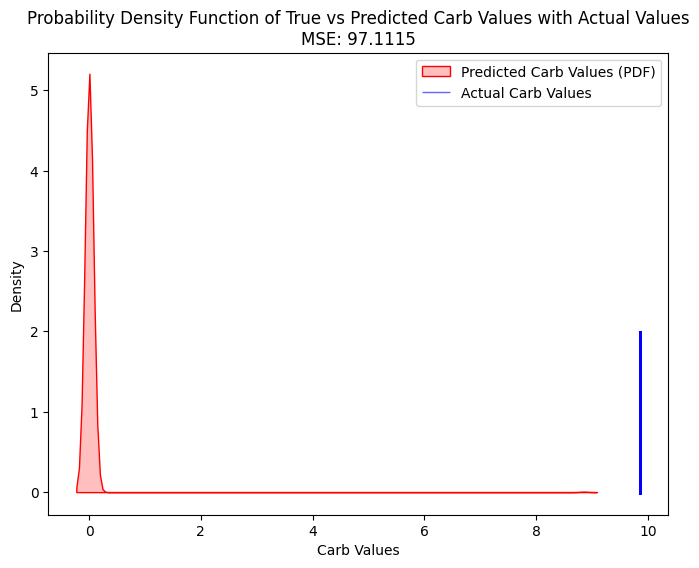

In [ ]:
# Split the data into training and testing sets based on the masks
X_train = normalized_signals[train_mask]
X_test = normalized_signals[test_mask]
y_train = labels[train_mask]
y_test = labels[test_mask]

row_means = np.mean(X_train, axis=1, keepdims=True)
X_train = X_train - row_means
row_means = np.mean(X_test, axis=1, keepdims=True)
X_test = X_test - row_means

# Extract carbohydrate targets
carb_targets = targets[:, 0]  # Assuming carbs are the first element in the target array
X_train_reg = encoded_data[train_mask]
X_test_reg = encoded_data[test_mask]
y_train_reg = carb_targets[train_mask]
y_test_reg = carb_targets[test_mask]

# Step 1: Train the classifier using Logistic Regression
classifier = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500)
classifier.fit(X_train, y_train)

# Step 2: Get predicted classes for X_test
predicted_classes = classifier.predict(X_test)  # Predicted class for each test sample

# Step 3: Train regressors (neural networks) for each class based on carb targets
unique_classes = np.unique(y_train)
regressors = {}

# Define a function to create a simple neural network model for regression
def create_nn_model(input_shape):
    model = Sequential()
    model.add(Input(shape=(input_shape,)))  # Specify the input shape using Input layer
    model.add(Dense(64, activation='relu'))  # Hidden layer with 64 neurons
    model.add(Dense(32, activation='relu'))  # Hidden layer with 32 neurons
    model.add(Dense(1))  # Output layer for regression
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Train a neural network regressor for each unique class
for category in unique_classes:
    mask = (y_train == category)
    regressor = create_nn_model(X_train_reg.shape[1])
    regressor.fit(X_train_reg[mask], y_train_reg[mask], epochs=50, batch_size=32, verbose=0)  # Train NN
    regressors[category] = regressor

# Step 4: Use the regressor of the predicted class to predict carb values
carb_predictions = np.zeros(len(X_test_reg))

for i in range(len(X_test_reg)):
    predicted_class = predicted_classes[i]  # Get the predicted class for the sample
    # Use the neural network regressor for the predicted class to get the carb prediction
    carb_predictions[0] = regressors[predicted_class].predict(np.array([X_test_reg[0]]), verbose=0)[0][0]

# Step 5: Evaluate (assuming you have actual carb values for X_test)
mse = mean_squared_error(y_test_reg, carb_predictions)
print(f"Mean Squared Error for Carb Predictions: {mse}")

# Step 6: Visualize the classification results using a confusion matrix
overall_accuracy = accuracy_score(y_test, predicted_classes)
print(f"Overall Classification Accuracy: {overall_accuracy * 100:.2f}%")

# Step 7: Visualize the regression results using PDF
plt.figure(figsize=(8, 6))
# Plot the PDF of the predicted carb values (carb_predictions)
sns.kdeplot(carb_predictions, label='Predicted Carb Values (PDF)', color='red', fill=True)
# Overlay the actual carb values as longer vertical lines
plt.vlines(y_test_reg, ymin=-0.02, ymax=2, color='blue', alpha=0.6, linewidth=1, label='Actual Carb Values')
# Add labels and title
plt.title(f'Probability Density Function of True vs Predicted Carb Values with Actual Values\nMSE: {mse:.4f}')
plt.xlabel('Carb Values')
plt.ylabel('Density')
plt.legend()
plt.show()

# Full Code

In [ ]:
# Loop through each class in the category_mapping
for class_name in category_mapping.keys():
    test_classes = [class_name]  # Use the current class as the test set
    test_classes =    # Use the current class as the test set

    # Apply class mapping
    categories = [category_mapping[class_name] for class_name in class_names]

    # Encode categories and one-hot encode labels for CNN
    label_encoder = LabelEncoder()
    labels = label_encoder.fit_transform(categories)
    labels_one_hot = to_categorical(labels)

    # Create masks for train and test sets
    test_mask = np.isin(class_names, test_classes)
    train_mask = ~test_mask

    # Convert dataset to NumPy array
    data = np.array(normalized_signals)
    input_dim = data.shape[1]

    # Define encoder network
    input_layer = Input(shape=(input_dim,))
    encoded = Dense(256, activation='relu')(input_layer)
    encoded = Dense(128, activation='relu')(encoded)
    encoded = Dense(64, activation='relu')(encoded)
    encoded = Dense(32, activation='relu')(encoded)
    encoded = Dense(2, activation='linear')(encoded)

    # Define decoder network (optional)
    decoded = Dense(64, activation='relu')(encoded)
    decoded = Dense(128, activation='relu')(decoded)
    decoded = Dense(input_dim, activation='sigmoid')(decoded)

    # Compile autoencoder and encoder models
    autoencoder = Model(input_layer, decoded)
    encoder = Model(input_layer, encoded)
    autoencoder.compile(optimizer=Adam(), loss='mse')

    # Train autoencoder
    autoencoder.fit(data, data, epochs=50, batch_size=256, shuffle=True)
    encoded_data = encoder.predict(data)

    # Split data based on masks
    X_train, X_test = normalized_signals[train_mask], normalized_signals[test_mask]
    y_train, y_test = labels_one_hot[train_mask], labels_one_hot[test_mask]

    # Normalize data by subtracting row means
    X_train -= np.mean(X_train, axis=1, keepdims=True)
    X_test -= np.mean(X_test, axis=1, keepdims=True)

    # Extract carb targets
    carb_targets = targets[:, 0]
    X_train_reg, X_test_reg = encoded_data[train_mask], encoded_data[test_mask]
    y_train_reg, y_test_reg = carb_targets[train_mask], carb_targets[test_mask]

        # Define a CNN classifier model
    input_shape = (X_train.shape[1], 1)  # Assuming 1D signals
    cnn_model = Sequential()
    cnn_model.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=input_shape))
    cnn_model.add(MaxPooling1D(pool_size=2))
    cnn_model.add(Conv1D(128, kernel_size=3, activation='relu'))
    cnn_model.add(MaxPooling1D(pool_size=2))
    cnn_model.add(Flatten())
    cnn_model.add(Dense(128, activation='relu'))
    cnn_model.add(Dropout(0.5))
    cnn_model.add(Dense(y_train.shape[1], activation='softmax'))  # Output layer

    # Compile the model
    cnn_model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

    # Reshape data for CNN input
    X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

    # Train the CNN model
    cnn_model.fit(X_train_cnn, y_train, epochs=20, batch_size=64, validation_data=(X_test_cnn, y_test), verbose=1)

    # Get class probabilities for X_test
    class_probabilities = cnn_model.predict(X_test_cnn)

    # Train linear regressors for each class based on carb targets
    unique_classes = np.unique(labels[train_mask])
    regressors = {category: LinearRegression() for category in unique_classes}
    for category in unique_classes:
        mask = (labels[train_mask] == category)
        regressors[category].fit(X_train_reg[mask], y_train_reg[mask])

    # Predict carb values using class probabilities
    carb_predictions = np.zeros(len(X_test_reg))
    for i in range(len(X_test_reg)):
        weighted_sum = sum(class_probabilities[i][j] * regressors[category].predict([X_test_reg[i]])[0]
                           for j, category in enumerate(unique_classes))
        carb_predictions[i] = weighted_sum

    # Calculate and print MSE for carb predictions
    mse = mean_squared_error(y_test_reg, carb_predictions)
    print(f"Mean Squared Error for Carb Predictions: {mse}")

    # Calculate and print classification accuracy
    predicted_classes = np.argmax(class_probabilities, axis=1)  # Get the predicted class labels
    true_classes = np.argmax(y_test, axis=1)  # Convert one-hot encoded y_test to class labels
    overall_accuracy = accuracy_score(true_classes, predicted_classes)
    print(f"Overall Classification Accuracy: {overall_accuracy * 100:.2f}%")


    # Plot the normalized PDF of carb predictions and save as PNG
    plt.figure(figsize=(8, 6))
    sns.kdeplot(carb_predictions, label='Predicted Carb Values (PDF)', color='red', fill=True, common_norm=True)
    plt.vlines(y_test_reg, ymin=-0.02, ymax=1, color='blue', alpha=0.6, linewidth=1, label='Actual Carb Values')
    plt.title(f'{class_name} - Normalized PDF of True vs Predicted Carb Values\nMSE: {mse:.4f} Classification Accuracy: {overall_accuracy * 100:.2f}%')
    plt.xlabel('Carb Values')
    plt.ylabel('Density (Normalized)')
    plt.legend()

    # Save the plot as PNG
    plot_filename = f'{class_name}_carb_prediction_normalized.png'
    plt.savefig(plot_filename)
    plt.close()  # Close the figure to avoid memory overload



Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.1416
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0642
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0517
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0417
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0334
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0292
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0277
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0307
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0290
Epoch 10/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0270
Epoch 11/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0272
Epoch 12/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0264
Epoch 13/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0273
Epoch 14/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0260
Epoch 15/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0253
Epoch 16/50
28/28 

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


108/108 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.7578 - loss: 0.8292 - val_accuracy: 0.2450 - val_loss: 2.4069
Epoch 2/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9516 - loss: 0.1556 - val_accuracy: 0.2250 - val_loss: 2.8695
Epoch 3/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9624 - loss: 0.1128 - val_accuracy: 0.1650 - val_loss: 4.0057
Epoch 4/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9749 - loss: 0.0829 - val_accuracy: 0.0500 - val_loss: 4.8639
Epoch 5/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9748 - loss: 0.0764 - val_accuracy: 0.0850 - val_loss: 6.9462
Epoch 6/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9768 - loss: 0.0720 - val_accuracy: 0.0950 - val_loss: 5.1428
Epoch 7/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9804 - loss: 0.0549 - val_accuracy: 0.0350 - val_loss: 6.5023
Epoch 8/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9725 - loss: 0.0701 - val_accuracy: 0.1300 - val

222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


108/108 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.7551 - loss: 0.8402 - val_accuracy: 0.1400 - val_loss: 2.8192
Epoch 2/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9442 - loss: 0.1772 - val_accuracy: 0.2000 - val_loss: 2.6269
Epoch 3/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9652 - loss: 0.1105 - val_accuracy: 0.1600 - val_loss: 3.3136
Epoch 4/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9739 - loss: 0.0854 - val_accuracy: 0.1200 - val_loss: 4.1666
Epoch 5/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9753 - loss: 0.0787 - val_accuracy: 0.1500 - val_loss: 4.0518
Epoch 6/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9780 - loss: 0.0628 - val_accuracy: 0.1700 - val_loss: 3.9181
Epoch 7/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9851 - loss: 0.0470 - val_accuracy: 0.0350 - val_loss: 5.4080
Epoch 8/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9841 - loss: 0.0459 - val_accuracy: 0.0300 - val

222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7459 - loss: 0.8618

KeyboardInterrupt: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# CNN Model
def create_cnn_model(input_shape, num_classes):
    model = Sequential()
    model.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.3))
    model.add(Conv1D(128, kernel_size=3, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.3))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Training CNN
input_shape = (X_train.shape[1], 1)
num_classes = len(np.unique(labels))

X_train_cnn = np.expand_dims(X_train, axis=2)  # Add channel dimension for CNN
X_test_cnn = np.expand_dims(X_test, axis=2)

row_means = np.mean(X_train_cnn, axis=1, keepdims=True)
X_train_cnn = X_train_cnn - row_means
row_means = np.mean(X_test_cnn, axis=1, keepdims=True)
X_test_cnn = X_test_cnn - row_means

cnn_model = create_cnn_model(input_shape, num_classes)
cnn_model.fit(X_train_cnn, labels_one_hot[train_mask],
              epochs=10,
              batch_size=32,
              validation_data=(X_test_cnn, labels_one_hot[test_mask]),
              verbose=1)
# Evaluate CNN
cnn_predictions = cnn_model.predict(X_test_cnn)
cnn_pred_labels = np.argmax(cnn_predictions, axis=1)
cnn_accuracy = accuracy_score(y_test, cnn_pred_labels)
print(f'CNN Accuracy: {cnn_accuracy:.2f}')

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.7687 - loss: 0.7118 - val_accuracy: 0.9900 - val_loss: 0.0300
Epoch 2/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.9493 - loss: 0.1615 - val_accuracy: 0.9889 - val_loss: 0.0370
Epoch 3/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.9592 - loss: 0.1194 - val_accuracy: 0.9989 - val_loss: 0.0094
Epoch 4/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.9668 - loss: 0.0971 - val_accuracy: 0.9989 - val_loss: 0.0118
Epoch 5/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.9753 - loss: 0.0722 - val_accuracy: 0.9744 - val_loss: 0.0891
Epoch 6/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.9748 - loss: 0.0690 - val_accuracy: 0.9989 - val_loss: 0.0104
Epoch 7/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.9818 - loss: 0.0603 - val_accuracy: 0.9989 - val_loss: 0.0061
Epoch 8/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.9821 - loss: 0.0557 - val_acc

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Dense, Lambda


# Assuming normalized_signals is your dataset
data = np.array(normalized_signals)  # Make sure your dataset is a NumPy array
input_dim = data.shape[1]

# Define the input layer
input_layer = Input(shape=(input_dim,))

# Encoder: Reduce to 2D latent space
encoded = Dense(256, activation='relu')(input_layer)
encoded = Dense(128, activation='relu')(encoded)
encoded = Dense(64, activation='relu')(encoded)
encoded = Dense(32, activation='relu')(encoded)
encoded = Dense(32, activation='linear')(encoded)  # 2D latent space
#encoded = Lambda(lambda x: tf.math.log(tf.nn.softplus(0.01*x)))(encoded)
#encoded = Lambda(lambda x: tf.math.log(x+12))(encoded)


# Decoder: Reconstruct from 2D latent space (optional for training)
decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

# Autoencoder model
autoencoder = Model(input_layer, decoded)
encoder = Model(input_layer, encoded)  # Encoder model for 2D output

# Compile the model
autoencoder.compile(optimizer=Adam(), loss='mse')

# Train the autoencoder
autoencoder.fit(data, data, epochs=100, batch_size=256, shuffle=True)

# Encode the data into 2D space
encoded_data = encoder.predict(data)

Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.1307
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - loss: 0.0597
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0444
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0330
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 148ms/step - loss: 0.0304
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 0.0290
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 0.0274
Epoch 8/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0280 
Epoch 9/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0265
Epoch 10/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0265
Epoch 11/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - loss: 0.0262
Epoch 12/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0261
Epoch 13/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - loss: 0.0261
Epoch 14/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0264
Epoch 15/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss

In [ ]:
reduced_signals = encoded_data
#reduced_signals = normalized_signals

In [ ]:
reduced_signals = encoded_data

# Extract carbohydrate targets
carb_targets = targets[:, 0]  # Assuming carbs are the first element in the target array

# Create masks for train and test sets
test_mask = np.isin(class_names, test_classes)
train_mask = ~test_mask

# Split the data into training and testing sets based on the masks
X_train = reduced_signals[train_mask]
X_test = reduced_signals[test_mask]
y_train = carb_targets[train_mask]
y_test = carb_targets[test_mask]

Linear Regression - Mean Squared Error: 10.712786877458178
Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 2.1298
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.4932
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.3243
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.2414
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.1848
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.1541
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.1404
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.1225
Epoch 9/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.1033
Epoch 10/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.0943
Epoch 11/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0721
Epoch 12/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0805
Epoch 13/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0782
Epoch 14/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0551
Epoch 15/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0

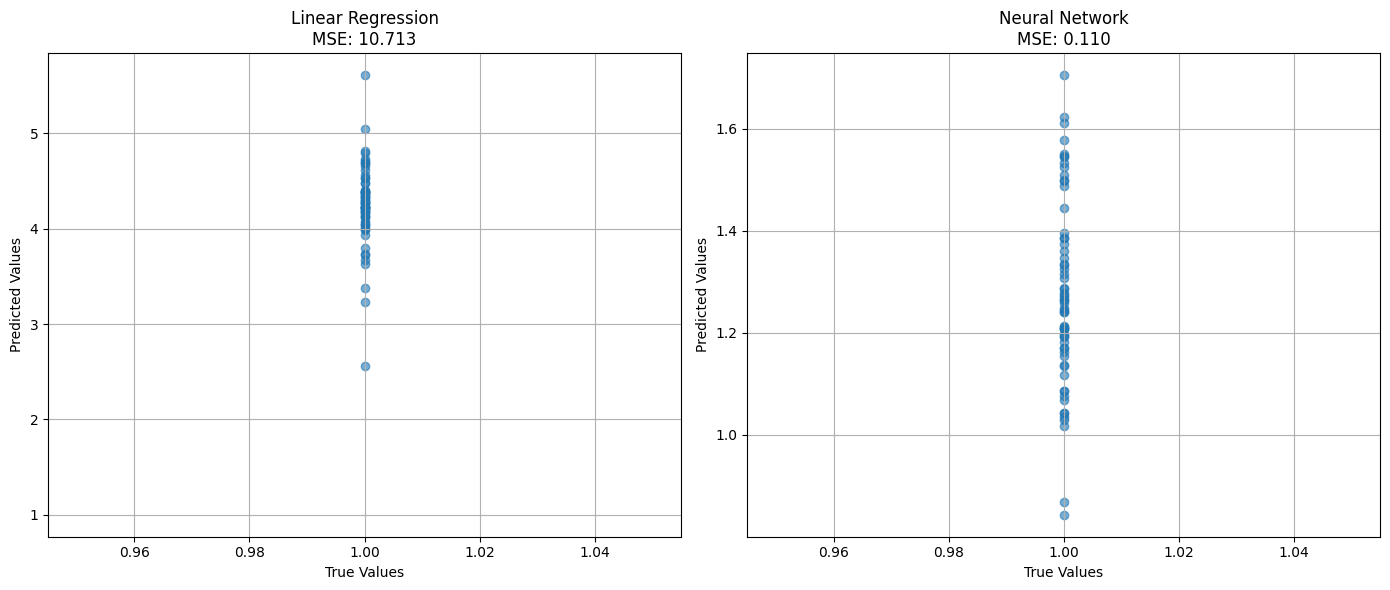

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Initialize the Linear Regression model
reg = LinearRegression()
# Train the Linear Regression model
reg.fit(X_train, y_train)
# Make predictions using Linear Regression
y_pred_lr = reg.predict(X_test)
# Calculate Mean Squared Error for Linear Regression
mse_lr = mean_squared_error(y_test, y_pred_lr)
print(f'Linear Regression - Mean Squared Error: {mse_lr}')

# Build the Neural Network model
model = Sequential([
    Dense(32, input_dim=X_train.shape[1], activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1)
])

# Compile the Neural Network model
model.compile(optimizer='adam', loss='mse')
# Train the Neural Network model
model.fit(X_train, y_train, epochs=20, batch_size=10, verbose=1)
# Make predictions using the Neural Network
y_pred_nn = model.predict(X_test).flatten()
# Calculate Mean Squared Error for the Neural Network
mse_nn = mean_squared_error(y_test, y_pred_nn)
print(f'Neural Network - Mean Squared Error: {mse_nn}')

# Plot the results
fig, axs = plt.subplots(1, 2, figsize=(14, 6))  # 1x2 grid for plotting

# Plot for Linear Regression
axs[0].scatter(y_test, y_pred_lr, alpha=0.6)
axs[0].plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')  # Line of perfect prediction
axs[0].set_title(f'Linear Regression\nMSE: {mse_lr:.3f}')
axs[0].set_xlabel('True Values')
axs[0].set_ylabel('Predicted Values')
axs[0].grid(True)

# Plot for Neural Network
axs[1].scatter(y_test, y_pred_nn, alpha=0.6)
axs[1].plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')  # Line of perfect prediction
axs[1].set_title(f'Neural Network\nMSE: {mse_nn:.3f}')
axs[1].set_xlabel('True Values')
axs[1].set_ylabel('Predicted Values')
axs[1].grid(True)

# Adjust layout and show plot
plt.tight_layout()
plt.show()


Random Forest - Mean Squared Error: 0.10204322222222222


KeyboardInterrupt: 

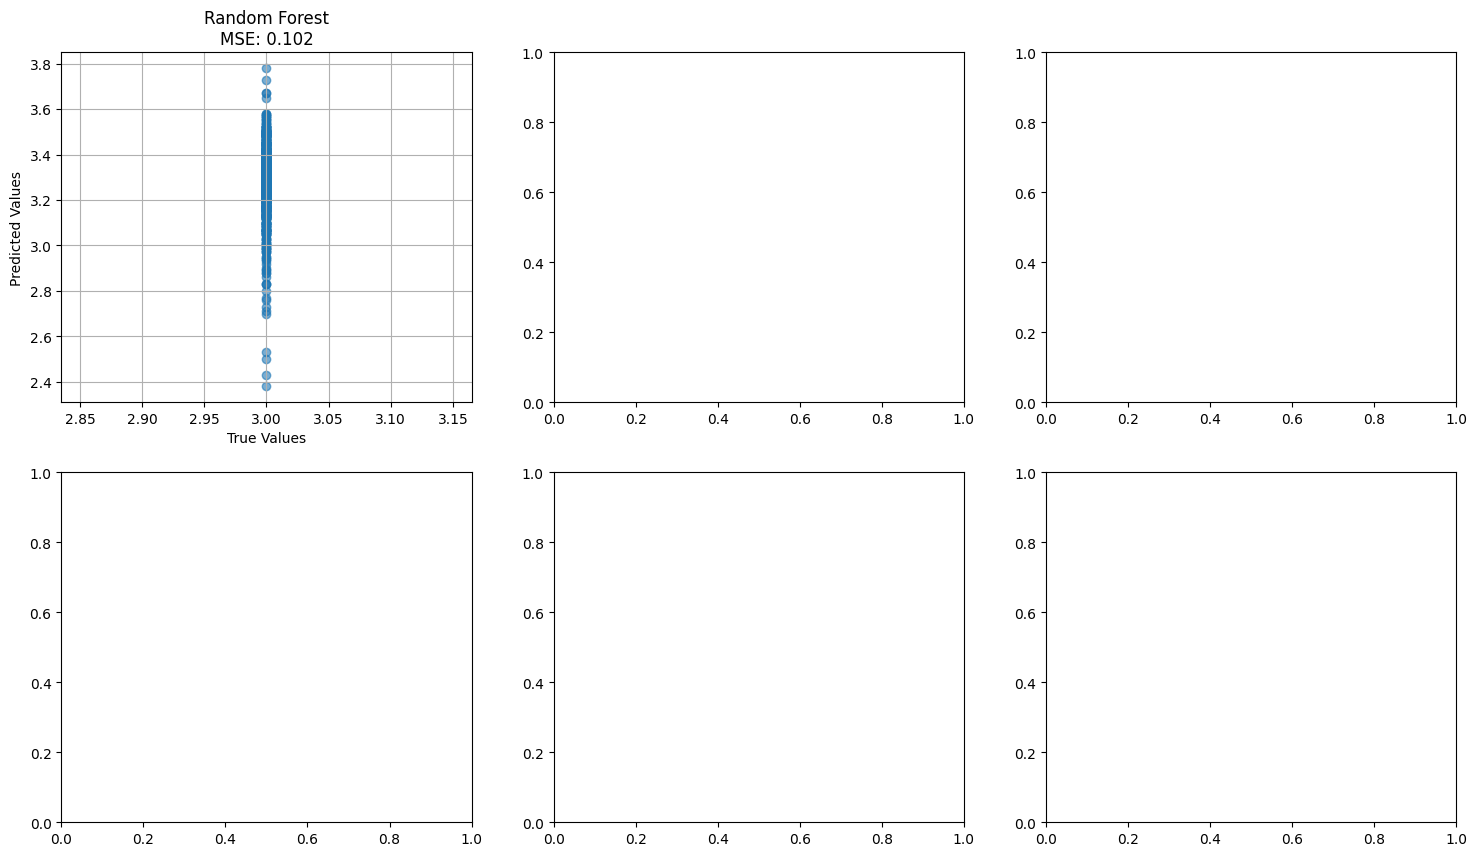

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Initialize different regressors
regressors = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostRegressor(n_estimators=100, random_state=42),
    'Linear Regression': LinearRegression(),
    'Support Vector Regressor': SVR()
}

# Create subplots for the scatter plots
fig, axs = plt.subplots(2, 3, figsize=(18, 10))  # 2x3 grid

for i, (name, reg) in enumerate(regressors.items()):
    reg.fit(X_train, y_train)
    y_pred = reg.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f'{name} - Mean Squared Error: {mse}')

    ax = axs[i//3, i%3]  # Determine position in the 2x3 grid
    ax.scatter(y_test, y_pred, alpha=0.6)
    ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')  # Line of perfect prediction
    ax.set_title(f'{name}\nMSE: {mse:.3f}')
    ax.set_xlabel('True Values')
    ax.set_ylabel('Predicted Values')
    ax.grid(True)

# Train and evaluate the neural network
model = Sequential([
    Dense(256, input_dim=X_train.shape[1], activation='relu'),
    Dense(128, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, batch_size=10, verbose=1)

y_pred_nn = model.predict(X_test).flatten()
mse_nn = mean_squared_error(y_test, y_pred_nn)
print(f'Neural Network - Mean Squared Error: {mse_nn}')

# Add Neural Network plot to the last subplot
ax = axs[1, 2]  # Last position in the 2x3 grid
ax.scatter(y_test, y_pred_nn, alpha=0.6)
ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')  # Line of perfect prediction
ax.set_title(f'Neural Network\nMSE: {mse_nn:.3f}')
ax.set_xlabel('True Values')
ax.set_ylabel('Predicted Values')
ax.grid(True)

# Adjust layout and show plot
plt.tight_layout()
plt.show()

# Combined Model

In [ ]:
num_categories = len(set(category_mapping.values()))  # Number of unique categories


In [ ]:
# Expand dimensions of normalized_signals to match the expected input shape for Conv1D
normalized_signals = np.expand_dims(normalized_signals, axis=-1)

# Derive input shape from normalized_signals and reshape to (x, 1)
input_shape = (normalized_signals.shape[1], 1)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, Model, Input
import numpy as np

# Example input shape and parameters
output_dim = 1  # Example output for regression

# Build the multi-stage CNN classifier model
def build_cnn_classifier(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = layers.Conv1D(32, kernel_size=3, activation='relu')(inputs)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Conv1D(64, kernel_size=3, activation='relu')(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Conv1D(128, kernel_size=3, activation='relu')(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(num_classes, activation='softmax')(x)
    return Model(inputs, x, name='cnn_classifier')

# Build the regressor model
def build_regressor(input_dim, hidden_dim, output_dim):
    inputs = Input(shape=(input_dim,))
    x = layers.Dense(hidden_dim, activation='relu')(inputs)
    x = layers.Dense(output_dim, activation='linear')(x)
    return Model(inputs, x, name='regressor')

# Combine the classifier and regressor into one model
def build_combined_model(input_shape, num_classes, output_dim):
    # Classifier branch
    classifier = build_cnn_classifier(input_shape, num_classes)

    # Input for the combined model
    inputs = Input(shape=input_shape)

    # Classifier output
    class_output = classifier(inputs)

    # Flatten the input before combining
    flat_inputs = layers.Flatten()(inputs)

    # Combine classifier output with the original input
    combined_features = layers.concatenate([class_output, flat_inputs])

    # Regressor branch
    regressor = build_regressor(num_classes + np.prod(input_shape), 128, output_dim)

    # Regression output
    regression_output = regressor(combined_features)

    # Combined model
    model = Model(inputs, [class_output, regression_output], name='combined_model')
    return model

# Example usage
# normalized_signals would be your input data array with shape (num_samples, 100, 1)
# class_names would be the corresponding class labels

# Convert class names to categorical using category_mapping
class_indices = np.array([category_mapping[class_name] for class_name in class_names])

# Prepare the model
input_shape = normalized_signals.shape[1:]  # Adjust based on actual data shape
model = build_combined_model(input_shape, num_classes, output_dim)

# Compile the model
model.compile(optimizer='adam',
              loss={'cnn_classifier': 'categorical_crossentropy', 'regressor': 'mse'},
              metrics={'cnn_classifier': 'accuracy', 'regressor': 'mse'})

# Display the model summary
model.summary()

# Convert class names to categorical indices using category_mapping
class_indices = np.array([category_mapping[class_name] for class_name in class_names])

# Convert class indices to one-hot encoded categories for classification
categories = tf.keras.utils.to_categorical(class_indices, num_classes)

# Extract regression targets from macronutrient_targets using class names
regression_targets = np.array([macronutrient_targets[class_name] for class_name in class_names])

# Fit the model
model.fit(normalized_signals, [categories, regression_targets], epochs=10, batch_size=32)



Model: "combined_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11            │ (None, 212, 1)         │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ cnn_classifier            │ (None, 7)              │         48,455 │ input_layer_11[0][0]   │
│ (Functional)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_3 (Flatten)       │ (None, 212)            │              0 │ input_layer_11[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_3             │ (None, 219)            │              0 │ cnn_classifier[0][0],  │
│ (Concatenate)             │                        │                │ flatten_3[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ regressor (Functional)    │ (None, 1)              │         28,289 │ concatenate_3[0][0]    │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 76,744 (299.78 KB)

 Trainable params: 76,744 (299.78 KB)

 Non-trainable params: 0 (0.00 B)

ValueError: invalid literal for int() with base 10: 'Coffee'

# Test

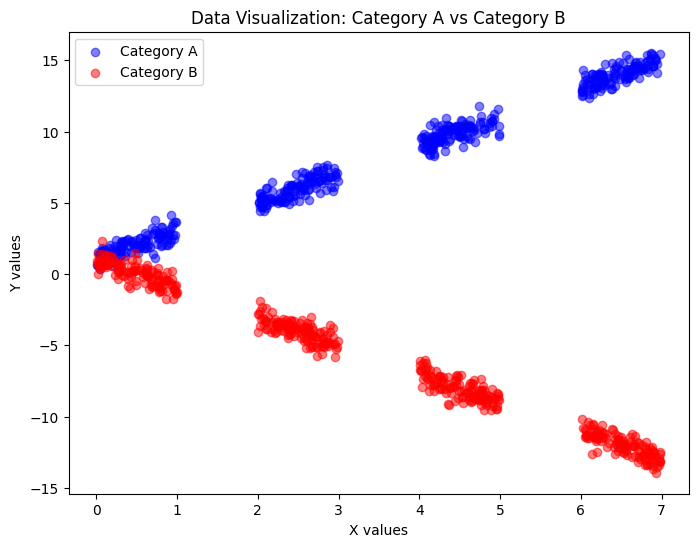

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.decomposition import PCA

# Seed for reproducibility
np.random.seed(42)

# Define function to generate data and calculate centroids
def generate_data_with_centroids(x_range, slope, intercept, size=125):
    x = np.random.uniform(x_range[0], x_range[1], size)
    y = slope * x + intercept + np.random.normal(scale=0.5, size=size)
    centroid = [np.mean(x), np.mean(y)]
    return x, y, centroid

# Generate data and centroids for each subclass in Category A
x_a1, y_a1, centroid_a1 = generate_data_with_centroids([0, 1], 2, 1)
x_a2, y_a2, centroid_a2 = generate_data_with_centroids([2, 3], 2, 1)
x_a3, y_a3, centroid_a3 = generate_data_with_centroids([4, 5], 2, 1)
x_a4, y_a4, centroid_a4 = generate_data_with_centroids([6, 7], 2, 1)

# Generate data and centroids for each subclass in Category B
x_b1, y_b1, centroid_b1 = generate_data_with_centroids([0, 1], -2, 1)
x_b2, y_b2, centroid_b2 = generate_data_with_centroids([2, 3], -2, 1)
x_b3, y_b3, centroid_b3 = generate_data_with_centroids([4, 5], -2, 1)
x_b4, y_b4, centroid_b4 = generate_data_with_centroids([6, 7], -2, 1)

# Combine data into a single dataset
X_a = np.hstack((x_a1, x_a2, x_a3, x_a4))
Y_a = np.hstack((y_a1, y_a2, y_a3, y_a4))

X_b = np.hstack((x_b1, x_b2, x_b3, x_b4))
Y_b = np.hstack((y_b1, y_b2, y_b3, y_b4))

# Labels for classification: 0 for Category A, 1 for Category B
labels_a = np.array([0]*500)
labels_b = np.array([1]*500)

# Reshape data for sklearn
features_a = np.vstack((X_a, Y_a)).T
features_b = np.vstack((X_b, Y_b)).T

# Targets should be the sum of the centroids
centroid_sums_a = np.array([
    np.sum(centroid_a1), np.sum(centroid_a2), np.sum(centroid_a3), np.sum(centroid_a4)
])
centroid_sums_b = np.array([
    np.sum(centroid_b1), np.sum(centroid_b2), np.sum(centroid_b3), np.sum(centroid_b4)
])

# Create the sum of centroids for all samples
y_sums_a = np.hstack((
    np.full(125, centroid_sums_a[0]),  # for x_a1
    np.full(125, centroid_sums_a[1]),  # for x_a2
    np.full(125, centroid_sums_a[2]),  # for x_a3
    np.full(125, centroid_sums_a[3])   # for x_a4
))
y_sums_b = np.hstack((
    np.full(125, centroid_sums_b[0]),  # for x_b1
    np.full(125, centroid_sums_b[1]),  # for x_b2
    np.full(125, centroid_sums_b[2]),  # for x_b3
    np.full(125, centroid_sums_b[3])   # for x_b4
))

# Construct the training set (excluding x_a3 and x_b1)
X_train = np.vstack((features_a[:250], features_a[375:], features_b[125:]))
labels_train = np.hstack((labels_a[:250], labels_a[375:], labels_b[125:]))
y_train = np.hstack((y_sums_a[:250], y_sums_a[375:], y_sums_b[125:]))

# Construct the testing set (x_a3 and x_b1)
X_test = np.vstack((features_a[250:375], features_b[:125]))
labels_test = np.hstack((labels_a[250:375], labels_b[:125]))
y_test = np.hstack((y_sums_a[250:375], y_sums_b[:125]))

import matplotlib.pyplot as plt

# Visualize the data for Category A and Category B
plt.figure(figsize=(8, 6))

# Plot Category A samples
plt.scatter(X_a[:500], Y_a[:500], color='blue', label='Category A', alpha=0.5)

# Plot Category B samples
plt.scatter(X_b[:500], Y_b[:500], color='red', label='Category B', alpha=0.5)

# Adding labels and title
plt.xlabel('X values')
plt.ylabel('Y values')
plt.title('Data Visualization: Category A vs Category B')

# Add legend
plt.legend()

# Show the plot
plt.show()


ValueError: x and y must be the same size

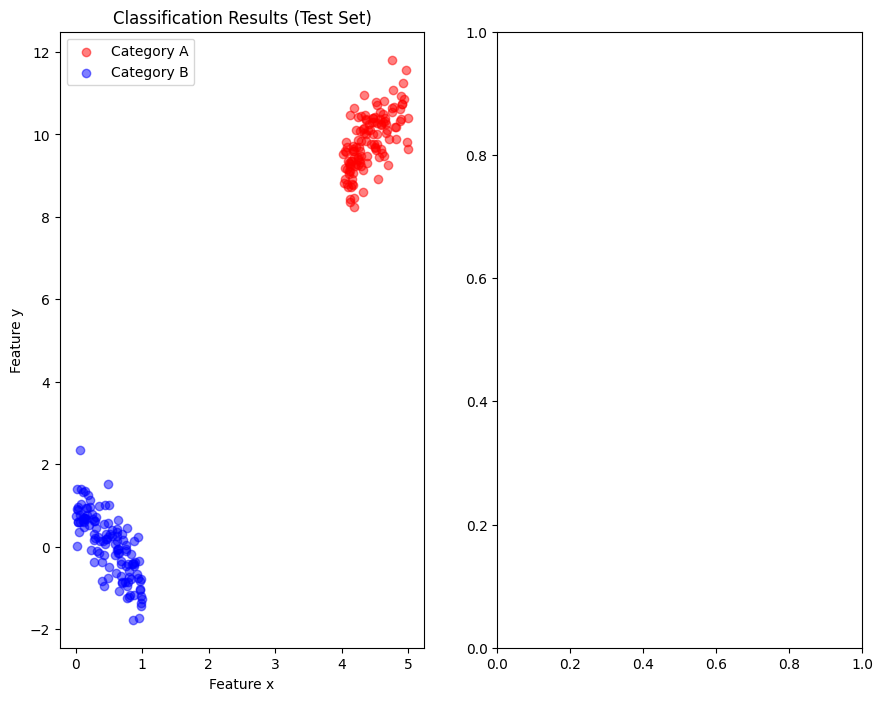

In [ ]:
from sklearn.svm import SVC

# -------- Step 1: Classifier -------- #
# Train a logistic regression classifier to classify between Category A and Category B
classifier = SVC(kernel='linear', C=1.0, probability=True, random_state=42)  # You can change 'kernel' to 'rbf', 'poly', etc.
classifier.fit(X_train, labels_train)

# Predict class labels for the training set
labels_pred = classifier.predict(X_train)
# -------- Step 2: Regressor -------- #
# Train a linear regression model to predict centroid values
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Make predictions for the regression model
y_pred = regressor.predict(X_test)

# -------- Visualization -------- #
plt.figure(figsize=(16, 8))



# Plot 2: Classification Results
plt.subplot(1, 3, 2)
for i, color in zip(range(2), ['red', 'blue']):
    idx = labels_test == i
    plt.scatter(X_test[idx, 0], X_test[idx, 1], c=color, label=f'Category {"A" if i == 0 else "B"}', alpha=0.5)
plt.title('Classification Results (Test Set)')
plt.xlabel('Feature x')
plt.ylabel('Feature y')
plt.legend()

# Plot 3: Regression Predictions
plt.subplot(1, 3, 3)
plt.scatter(X_test[:, 0], y_test, color='blue', label='Actual Centroid Values', alpha=0.5)
plt.scatter(X_test[:, 0], y_pred, color='magenta', label='Predicted Centroid Values', alpha=0.5)
plt.title('Regression Predictions')
plt.xlabel('Feature x')
plt.ylabel('Predicted Target Values')
plt.legend()

plt.tight_layout()
plt.show()


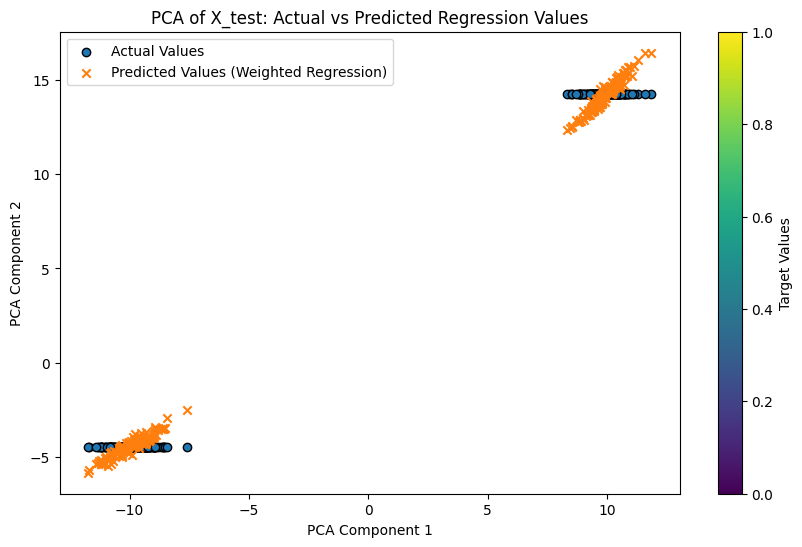

In [ ]:
# Perform PCA to reduce X_test to 2D if it's higher-dimensional
pca = PCA(n_components=1)
X_test_1D = pca.fit_transform(X_test)

# Plotting actual values vs. predicted regression values
plt.figure(figsize=(10, 6))

# Actual values (y_test) visualization
plt.scatter(X_test_1D[:, 0], y_test , label='Actual Values', marker='o', edgecolor='k')

# Predicted values (weighted regression)
plt.scatter(X_test_1D[:, 0], y_pred, label='Predicted Values (Weighted Regression)', marker='x')

plt.colorbar(label='Target Values')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA of X_test: Actual vs Predicted Regression Values')
plt.legend()
plt.show()

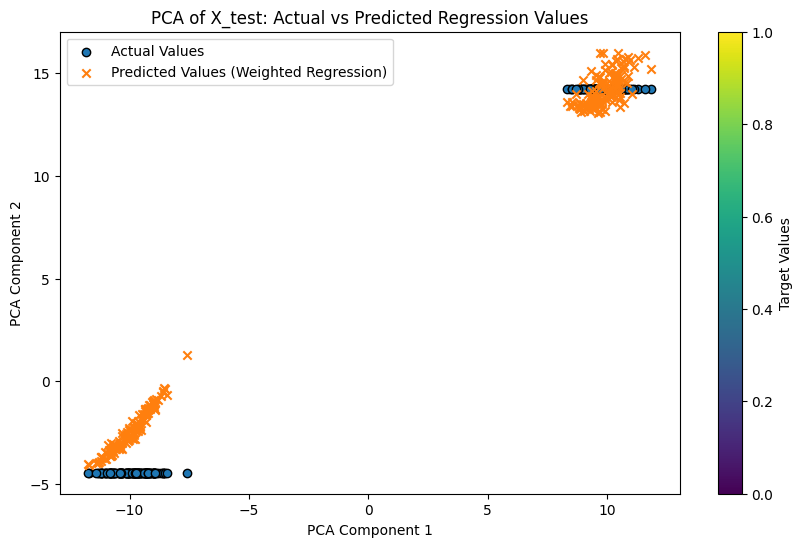

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split

# Train regressors for each class
regressor_A = LinearRegression()
regressor_B = LinearRegression()

# Train regressor A on class A data
regressor_A.fit(X_train[labels_train == 0], y_train[labels_train == 0])

# Train regressor B on class B data
regressor_B.fit(X_train[labels_train == 1], y_train[labels_train == 1])

# Initialize lists to store results
weighted_regressions = []
actual_values = []
class_probabilities_list = []

# Loop through all samples in X_test
for i in range(len(X_test)):
    sample = X_test[i].reshape(1, -1)

    # 1. Get class probabilities for the sample
    class_probabilities = classifier.predict_proba(sample)[0]

    # 2. Perform regression for both classes
    regression_A = regressor_A.predict(sample)
    regression_B = regressor_B.predict(sample)

    # 3. Weighted regression based on class probabilities
    weighted_regression = (class_probabilities[0] * regression_A +
                           class_probabilities[1] * regression_B)

    # Store results
    weighted_regressions.append(weighted_regression[0])  # store as scalar
    actual_values.append(y_test[i])
    class_probabilities_list.append(class_probabilities)

# Convert results to arrays for easy manipulation
weighted_regressions = np.array(weighted_regressions)
actual_values = np.array(actual_values)

# Perform PCA to reduce X_test to 2D if it's higher-dimensional
pca = PCA(n_components=1)
X_test_1D = pca.fit_transform(X_test)

# Plotting actual values vs. predicted regression values
plt.figure(figsize=(10, 6))

# Actual values (y_test) visualization
plt.scatter(X_test_1D[:, 0], actual_values , label='Actual Values', marker='o', edgecolor='k')

# Predicted values (weighted regression)
plt.scatter(X_test_1D[:, 0], weighted_regressions, label='Predicted Values (Weighted Regression)', marker='x')

plt.colorbar(label='Target Values')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA of X_test: Actual vs Predicted Regression Values')
plt.legend()
plt.show()


# Plots

In [ ]:
!pip install anytree

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 4.1 MB/s eta 0:00:00


In [ ]:
from anytree import Node, RenderTree
from anytree.exporter import UniqueDotExporter

# Define the tree structure
root = Node("Liquid Foods")

# Water-Based Beverages
water_based = Node("Water-Based Beverages", parent=root)
Node("water", parent=water_based)

# Dairy-Based Beverages
dairy_based = Node("Dairy-Based Beverages", parent=root)
plain_milk = Node("Plain Milk", parent=dairy_based)
Node("milk_1%", parent=plain_milk)
Node("milk_2%", parent=plain_milk)
Node("milk_whole", parent=plain_milk)
Node("whole_milk", parent=plain_milk)

sweetened_milk = Node("Sweetened Milk", parent=dairy_based)
Node("milk_1%_sugar_1cup", parent=sweetened_milk)
Node("milk_1%_sugar_2cup", parent=sweetened_milk)
Node("milk_1%_sugar_3cup", parent=sweetened_milk)
Node("milk_2%_sugar_1cup", parent=sweetened_milk)
Node("milk_2%_sugar_2cup", parent=sweetened_milk)
Node("milk_2%_sugar_3cup", parent=sweetened_milk)
Node("milk_whole_sugar_1cup", parent=sweetened_milk)
Node("milk_whole_sugar_2cup", parent=sweetened_milk)
Node("milk_whole_sugar_3cup", parent=sweetened_milk)
Node("whole_milk_sugar_1cup", parent=sweetened_milk)
Node("whole_milk_sugar_2cup", parent=sweetened_milk)
Node("whole_milk_sugar_3cup", parent=sweetened_milk)

flavored_milk = Node("Flavored Milk", parent=dairy_based)
Node("chocolate_milk", parent=flavored_milk)

# Caffeinated Beverages
caffeinated = Node("Caffeinated Beverages", parent=root)
plain_coffee_tea = Node("Plain Coffee and Tea", parent=caffeinated)
Node("coffee_8sp", parent=plain_coffee_tea)
Node("tea_6bags", parent=plain_coffee_tea)

coffee_tea_milk = Node("Coffee and Tea with Milk", parent=caffeinated)
Node("coffee_8sp_milk_400", parent=coffee_tea_milk)
Node("coffee_8sp_milk_800", parent=coffee_tea_milk)
Node("tea_6bags_milk_400", parent=coffee_tea_milk)

coffee_tea_milk_sugar = Node("Coffee and Tea with Milk and Sugar", parent=caffeinated)
Node("coffee_8sp_milk_800_sugar_1cup", parent=coffee_tea_milk_sugar)
Node("coffee_8sp_milk_800_sugar_2cup", parent=coffee_tea_milk_sugar)
Node("tea_6bags_milk_400_sugar_1cup", parent=coffee_tea_milk_sugar)

# Sweetened Beverages
sweetened = Node("Sweetened Beverages", parent=root)
carbonated = Node("Carbonated Beverages", parent=sweetened)
Node("coke", parent=carbonated)
Node("dietcoke", parent=carbonated)
Node("fanta", parent=carbonated)
Node("sprite", parent=carbonated)
Node("ginger", parent=carbonated)
Node("ginger_zero", parent=carbonated)

sugar_additives = Node("Standalone Sugar Additives", parent=sweetened)
Node("sugar1cup", parent=sugar_additives)
Node("sugar2cup", parent=sugar_additives)
Node("sugar3cup", parent=sugar_additives)
Node("sugar3.2cup", parent=sugar_additives)
Node("sugar3.4cup", parent=sugar_additives)
Node("sugar3.6cup", parent=sugar_additives)
Node("sugar3.8cup", parent=sugar_additives)
Node("sugar4cup", parent=sugar_additives)
Node("sugar5cup", parent=sugar_additives)
Node("sugar6cup", parent=sugar_additives)

# Export the tree to a DOT file for visualization
UniqueDotExporter(root).to_dotfile("liquid_food_tree.dot")

# Convert the DOT file to a PNG image (requires Graphviz installed)
import os
os.system("dot -Tpng liquid_food_tree.dot -o liquid_food_tree.png")

# The output image will be saved as "liquid_food_tree.png"
print("Tree plot saved as 'liquid_food_tree.png'.")


Tree plot saved as 'liquid_food_tree.png'.
